# **A Study on Noise Sensitivity and Explanation Stability in Safety-Critical Machine Learning Systems**

---
**Dataset Focus**: Records individual household electricity consumption via submeters in three areas.

**Collection Frequency:** Minute-averaged measurements for active/reactive power, voltage, and current intensity.

**Submeters:**

* Sub_metering_1: Kitchen appliances (dishwasher, oven, microwave).

* Sub_metering_2: Laundry room (washing machine, tumble-drier, refrigerator, light).

* Sub_metering_3: Electric water-heater and air-conditioner.

**Global Power:** global_active_power and global_reactive_power measure overall household energy usage.

**Missing Values:** ~1.25% rows have missing measurements.

**Time Stamps:** All calendar timestamps present; missing values appear as empty entries.

---

**Dataset Link :** https://www.kaggle.com/datasets/imtkaggleteam/household-power-consumption/data

> **Research Question :**

1. How does input noise affect the predictive performance of machine learning models trained on household power consumption data?
2. Can explainability method like LIME help identify robustness weaknesses in safety-critical machine learning systems?
3. How do feature importance and local explanations change when noise is introduced into sensor inputs?


# **Imports and Setup**

In [ ]:
!pip install lime

In [ ]:
# Data Handling
import pandas as pd
import numpy as np
import calendar
import json
import joblib

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-Learn - Preprocessing and Model Selection
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [ ]:
# Scikit-Learn - Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Scikit-Learn - Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras - Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Input,
    Conv1D,
    Flatten,
    Dropout,
    BatchNormalization,
    MultiHeadAttention,
    LayerNormalization,
    Add
)
from tensorflow.keras.optimizers import Adam

# Explainable AI
import lime
import lime.lime_tabular

# **Data Loading**

In [ ]:
# It loads the "Household Power Consumption" dataset collected from the Kaggle
power_consumption_data = pd.read_csv("/content/household_power_consumption.csv")

# It display first few rows to understand structure
power_consumption_data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


## **Data Shape**

In [ ]:
# It check dataset shape
print("."*35)
print("\t<<< Dataset shape >>>")
print("."*35)
print("\tRows   :", power_consumption_data.shape[0])
print("\tColumns:", power_consumption_data.shape[1])
print("."*35)

...................................
	<<< Dataset shape >>>
...................................
	Rows   : 1048575
	Columns: 9
...................................


> This dataset contains 1,048,575 rows and 9 columns which indicates a large structured dataset suitable for machine learning.


## **Data Type**

In [ ]:
# Inspect data types
print("."*35)
print("\t<<< Data Types >>>")
print("."*35)
print(power_consumption_data.dtypes)

...................................
	<<< Data Types >>>
...................................
Date                      object
Time                      object
Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object


> Most variables are stored as object instead of numeric which indicates incorrect data types. Date and Time need conversion to datetime, while power and voltage features require numeric casting for accurate analysis and modelling.


In [ ]:
# List of columns to convert
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

# Convert to numeric
for col in numeric_cols:
    power_consumption_data[col] = pd.to_numeric(power_consumption_data[col], errors='coerce')

In [ ]:
# Inspect data types
print("."*35)
print("\t<<< Data Types >>>")
print("."*35)
print(power_consumption_data.dtypes)

...................................
	<<< Data Types >>>
...................................
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [ ]:
# Convert date and time columns
power_consumption_data['Date'] = pd.to_datetime(power_consumption_data['Date'], format='%d/%m/%Y')
power_consumption_data['Time'] = pd.to_datetime(power_consumption_data['Time'], format='%H:%M:%S').dt.time

In [ ]:
# Check data types after conversion
print("."*40)
print("\t<<< Data Types >>>")
print("."*40)
print(power_consumption_data.dtypes)

........................................
	<<< Data Types >>>
........................................
Date                     datetime64[ns]
Time                             object
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
dtype: object


> Date converted to datetime improving temporal analysis. All measurement fields now float64 enabling numerical processing. Time remains object. Numeric types support aggregation, correlation and modelling while reducing errors and reliability.


## **Missing Values**

In [ ]:
# Count total missing values in each column
missing_counts = power_consumption_data.isnull().sum()

# Calculate percentage of missing values for each column
missing_percent = (power_consumption_data.isnull().sum() / len(power_consumption_data)) * 100

# Create a df summarising missing values
missing_power_consumption_data = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage (%)": missing_percent
})

# Display the missing values summary
print("."*65)
print("\t"*5 + "<<< Missing Values >>>")
print("."*65)
missing_power_consumption_data

.................................................................
					<<< Missing Values >>>
.................................................................


,Missing Count,Missing Percentage (%)
Date,0,0.00000
Time,0,0.00000
Global_active_power,4069,0.38805
Global_reactive_power,4069,0.38805
Voltage,4069,0.38805
Global_intensity,4069,0.38805
Sub_metering_1,4069,0.38805
Sub_metering_2,4069,0.38805
Sub_metering_3,4069,0.38805


> Above df shows consistent missing values across all measurement features with 4069 records affected, representing 0.38805%. Date and Time contain no missing data, ensuring reliable temporal alignment for preprocessing and modelling.


In [ ]:
# Impute missing values with median
for col in numeric_cols:
    median_value = power_consumption_data[col].median()
    power_consumption_data[col] = power_consumption_data[col].fillna(median_value)

# Verify that missing values are filled
print("Missing Value Status After Imputation:",
      power_consumption_data[numeric_cols].isnull().sum().sum())

Missing Value Status After Imputation: 0


> Median imputation removed all missing data, improving dataset completeness and ensuring reliable analysis across all important numeric power consumption features.


## **Duplicates**

In [ ]:
# It checks the number of duplicate record present
duplicate_records = power_consumption_data.duplicated().sum()
print("Total Duplicate Records Found :", duplicate_records)

Total Duplicate Records Found : 0


> No duplicate records detected which confirms dataset uniqueness and ensuring reliable analysis without repeated entries affecting power consumption patterns or results

## **Statistical Summary**

In [ ]:
# Statistical Summary
power_consumption_data.describe()

,Date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,1048575,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,2007-12-15 07:31:23.412059392,1.106036e+00,1.181945e-01,2.399608e+02,4.709127e+00,1.172882e+00,1.469452e+00,5.910810e+00
min,2006-12-16 00:00:00,7.600000e-02,0.000000e+00,2.234900e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2007-06-16 00:00:00,2.880000e-01,0.000000e+00,2.379800e+02,1.200000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2007-12-15 00:00:00,5.500000e-01,9.800000e-02,2.402100e+02,2.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2008-06-14 00:00:00,1.542000e+00,1.860000e-01,2.421400e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,2008-12-13 00:00:00,1.067000e+01,1.390000e+00,2.521400e+02,4.640000e+01,8.000000e+01,7.800000e+01,3.100000e+01
std,NaN,1.127886e+00,1.093008e-01,3.278162e+00,4.756521e+00,6.309331e+00,6.341029e+00,8.202752e+00


> Data spans from 2006 to 2008, with an average date around late 2007 which indicating roughly two years of continuous household power consumption monitoring.

> Global active power averages about 1.1 kilowatts, but peaks above 10, showing occasional high energy demand periods.

> Voltage remains relatively stable near 240 volts, with small variation, suggesting a consistent electrical supply.

> Most sub metering values are zero at median level which indicates intermittent appliance usage rather than continuous consumption.

> Global intensity shows high variability, reaching above 46 amperes which reflects significant fluctuations in household electrical load over time.

# **Date-Time Feature Engineering**

In [ ]:
power_consumption_data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
# Combine Date and Time into a single Datetime column
power_consumption_data['Datetime'] = pd.to_datetime(
    power_consumption_data['Date'].astype(str) + ' ' + power_consumption_data['Time'].astype(str),
    format='%Y-%m-%d %H:%M:%S'
)

# Drop original Date and Time columns if you want
power_consumption_data.drop(['Date', 'Time'], axis=1, inplace=True)

In [ ]:
# Move 'Datetime' column to the start
cols = ['Datetime'] + [col for col in power_consumption_data.columns if col != 'Datetime']
power_consumption_data = power_consumption_data[cols]

# Reset index to make it a normal integer index
power_consumption_data.reset_index(drop=True, inplace=True)

In [ ]:
# Check the dataframe
power_consumption_data.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
# Extract useful temporal features
power_consumption_data["Hour"] = power_consumption_data["Datetime"].dt.hour
power_consumption_data["Day"] = power_consumption_data["Datetime"].dt.day
power_consumption_data["Month"] = power_consumption_data["Datetime"].dt.month
power_consumption_data["Weekday"] = power_consumption_data["Datetime"].dt.weekday

In [ ]:
# Check the dataframe
power_consumption_data.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,Weekday
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12,5
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12,5
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12,5
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12,5
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12,5


In [ ]:
# Function to convert to Camel Case with spaces
def camel_case_with_space(name):
    return ' '.join(word.capitalize() for word in name.split('_'))

# Rename columns
power_consumption_data.columns = [camel_case_with_space(col) for col in power_consumption_data.columns]

In [ ]:
# Check new column names
power_consumption_data.head()

,Datetime,Global Active Power,Global Reactive Power,Voltage,Global Intensity,Sub Metering 1,Sub Metering 2,Sub Metering 3,Hour,Day,Month,Weekday
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12,5
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12,5
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12,5
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12,5
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12,5


* The Datetime column represents the exact moment of measurement for each row, in "YYYY-MM-DD HH:MM:SS" format.
* Global Active Power measures the total real power consumed by the household at each minute. It is expressed in kilowatts (kW) and represents energy actually used to run appliances.
* Global Reactive Power measures the reactive component of electricity in the household. It indicates power stored and released by inductive or capacitive devices, measured in kilowatts (kW).
* Voltage represents the electrical potential difference supplied to the household. It is measured in volts (V) and indicates the strength of the electric current.
* Global Intensity measures the total current flowing through the household's electrical system. It is expressed in amperes (A) and reflects how much electricity is being drawn at that moment.
* Sub Metering 1, 2 and 3 measure energy consumption in specific areas of the household. They are recorded in watt-hours (Wh) for the kitchen, laundry room, and water-heater/air-conditioner, respectively.







In [ ]:
# Start date
start_date = power_consumption_data['Datetime'].min()

# End date
end_date = power_consumption_data['Datetime'].max()

print("Start Date:", start_date)
print("End Date  :", end_date)

Start Date: 2006-12-16 17:24:00
End Date  : 2008-12-13 21:38:00


It covers power consumption from December 2006 to December 2008 which provides nearly 2 years of continuous records and enabling detailed analysis of long term household electricity usage patterns.


# **Data Visulisation**

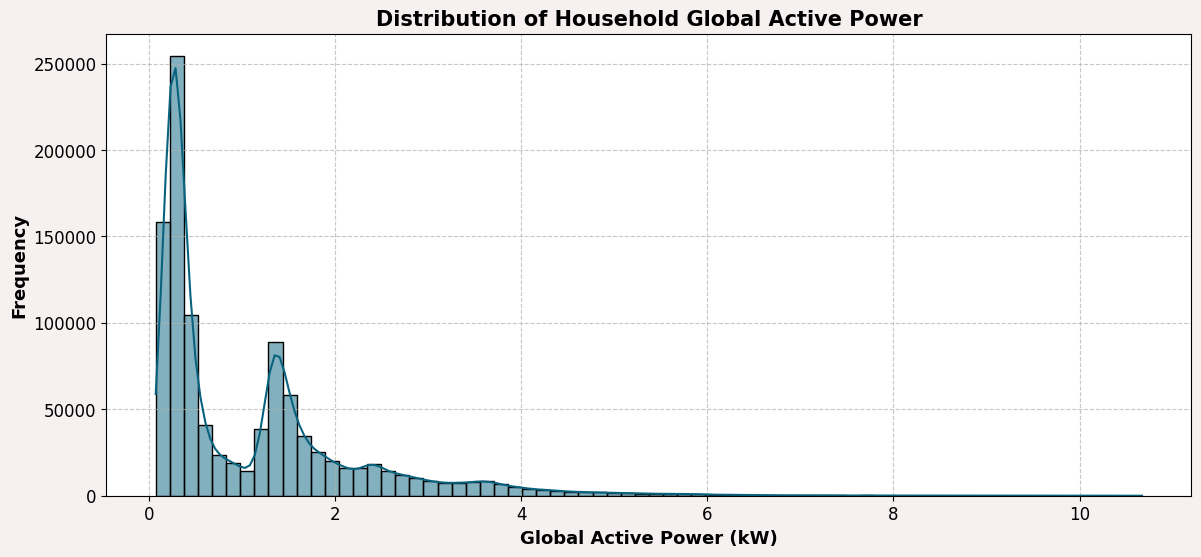

In [ ]:
# Plot histogram
plt.figure(figsize=(14, 6), facecolor="#F7F0F0")
sns.histplot(
    power_consumption_data['Global Active Power'],
    bins=70,
    color="#09637E",
    kde=True
)

# Add title, adjust labels and tick formattings
plt.title("Distribution of Household Global Active Power", fontsize=15, fontweight='bold')
plt.xlabel("Global Active Power (kW)", fontsize=13, fontweight='bold')
plt.ylabel("Frequency", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This histogram reveals a highly right-skewed distribution of household electricity usage, predominantly concentrated at lower levels. The primary peak occurs near 0.3 kilowatts, indicating high density for baseline standby power. A secondary, smaller peak near 1.5 kilowatts suggests periodic appliance activity, while consumption beyond 4 kilowatts is exceptionally rare.

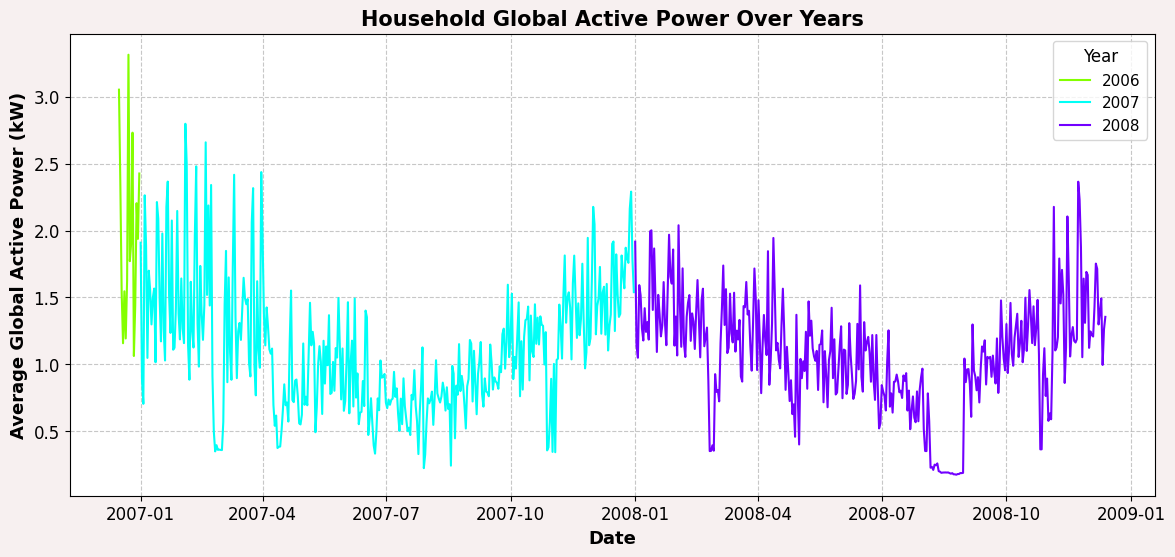

In [ ]:
# Extract year from Datetime
power_consumption_data['Year'] = power_consumption_data['Datetime'].dt.year

# Prepare figure
plt.figure(figsize=(14, 6), facecolor="#F7F0F0")

# Get a color palette based on number of years
years = power_consumption_data['Year'].unique()
colors = sns.color_palette("hsv", len(years))

# Plot daily averages for each year
for i, year in enumerate(sorted(years)):
    daily_year = power_consumption_data[power_consumption_data['Year'] == year] \
                 .resample('D', on='Datetime')['Global Active Power'].mean()
    plt.plot(daily_year.index, daily_year.values, color=colors[i], label=str(year))

# Add title, adjust labels and tick formattings
plt.title("Household Global Active Power Over Years", fontsize=15, fontweight='bold')
plt.xlabel("Date", fontsize=13, fontweight='bold')
plt.ylabel("Average Global Active Power (kW)", fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(title="Year", fontsize=11, title_fontsize=12)
plt.show()

This time-series plot demonstrates strong seasonal density in household energy consumption from 2006 to 2008. Demand peaks significantly during winter months, reaching above 3.0 kilowatts in late 2006. Usage drops to its lowest density during summer periods, often falling below 0.5 kilowatts, reflecting reduced heating or lighting requirements.

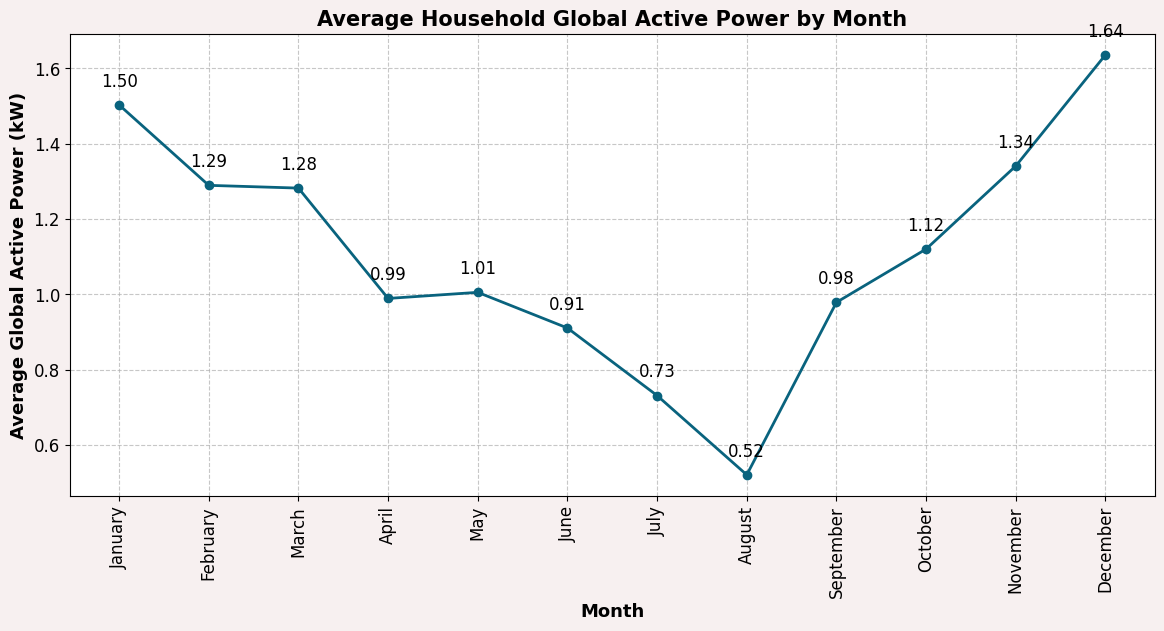

In [ ]:
# Aggregate by Month
monthly_avg = power_consumption_data.groupby('Month')['Global Active Power'].mean()

# Get full month names
months = [calendar.month_name[m] for m in monthly_avg.index]

# Plot line chart
plt.figure(figsize=(14, 6), facecolor="#F7F0F0")
plt.plot(months, monthly_avg.values, marker='o', color="#09637E", linewidth=2)

# Add title, adjust labels and tick formattings
plt.title("Average Household Global Active Power by Month", fontsize=15, fontweight='bold')
plt.xlabel("Month", fontsize=13, fontweight='bold')
plt.ylabel("Average Global Active Power (kW)", fontsize=13, fontweight='bold')
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate points
for i, v in enumerate(monthly_avg.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=12)
plt.show()

The line graph displays a clear seasonal density in energy usage. Consumption peaks in December at 1.64 kilowatts, followed by January at 1.50 kilowatts, indicating high winter demand. The lowest density occurs in August at 0.52 kilowatts, showing a significant reduction during the warmer summer months.

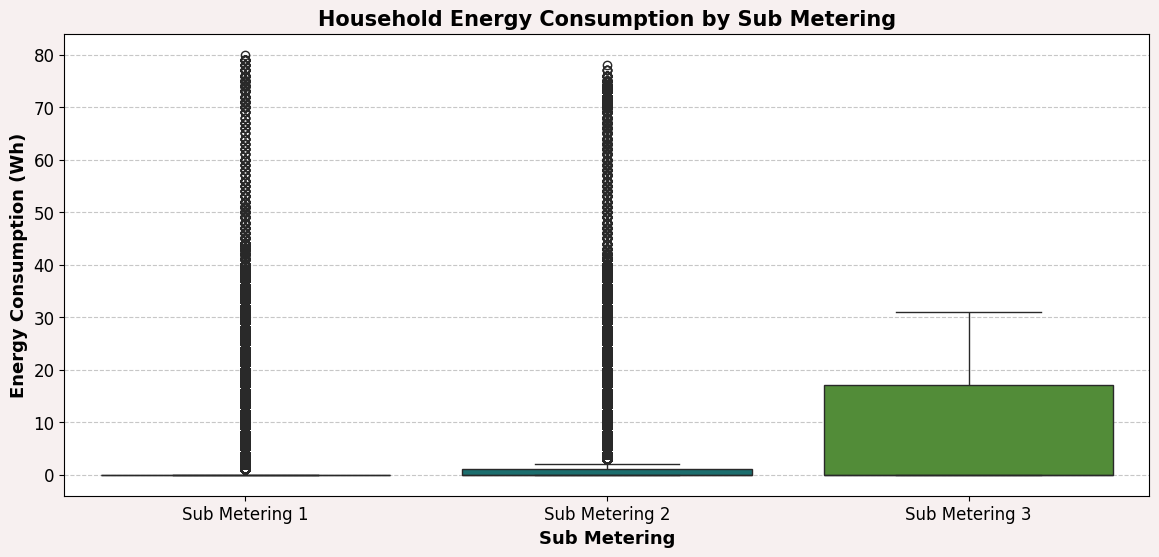

In [ ]:
# Select sub metering columns
sub_metering_cols = ['Sub Metering 1', 'Sub Metering 2', 'Sub Metering 3']

# Plot boxplots
plt.figure(figsize=(14, 6), facecolor="#F7F0F0")
sns.boxplot(data=power_consumption_data[sub_metering_cols], palette=["#09637E", "#0E7C7B", "#4C9A2A"])

# Add title, adjust labels and tick formattings
plt.title("Household Energy Consumption by Sub Metering", fontsize=15, fontweight='bold')
plt.xlabel("Sub Metering", fontsize=13, fontweight='bold')
plt.ylabel("Energy Consumption (Wh)", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Above box plot illustrates that Sub Metering 3 maintains the highest typical density of energy consumption, with a median significantly above Sub Metering 1 and 2. However, Sub Metering 1 and 2 exhibit extreme outlier density, with frequent spikes reaching 80 watt-hours, far exceeding their near-zero baseline levels.

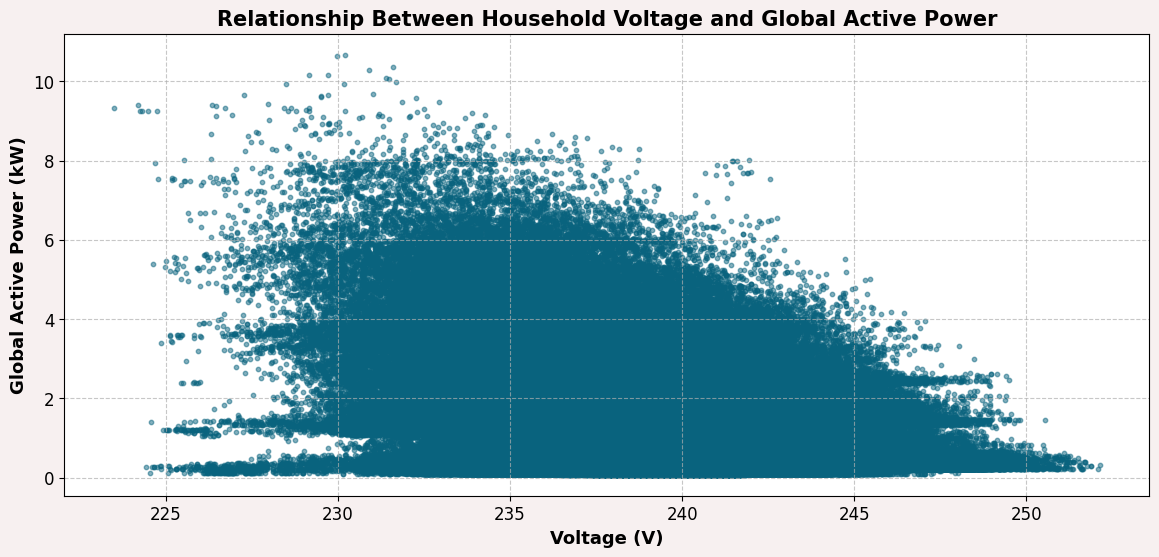

In [ ]:
# Scatter plot
plt.figure(figsize=(14, 6), facecolor="#F7F0F0")
plt.scatter(
    power_consumption_data['Voltage'],
    power_consumption_data['Global Active Power'],
    color="#09637E",
    alpha=0.5,
    s=10
)

# Add title, adjust labels and tick formattings
plt.title("Relationship Between Household Voltage and Global Active Power", fontsize=15, fontweight='bold')
plt.xlabel("Voltage (V)", fontsize=13, fontweight='bold')
plt.ylabel("Global Active Power (kW)", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Scatter plot displays a dense cluster of data points concentrated between 230 and 245 volts. While voltage remains relatively stable, the highest density of power consumption occurs below 6 kilowatts. A slight inverse relationship exists, as peak power levels above 10 kilowatts only appear at lower voltage readings.

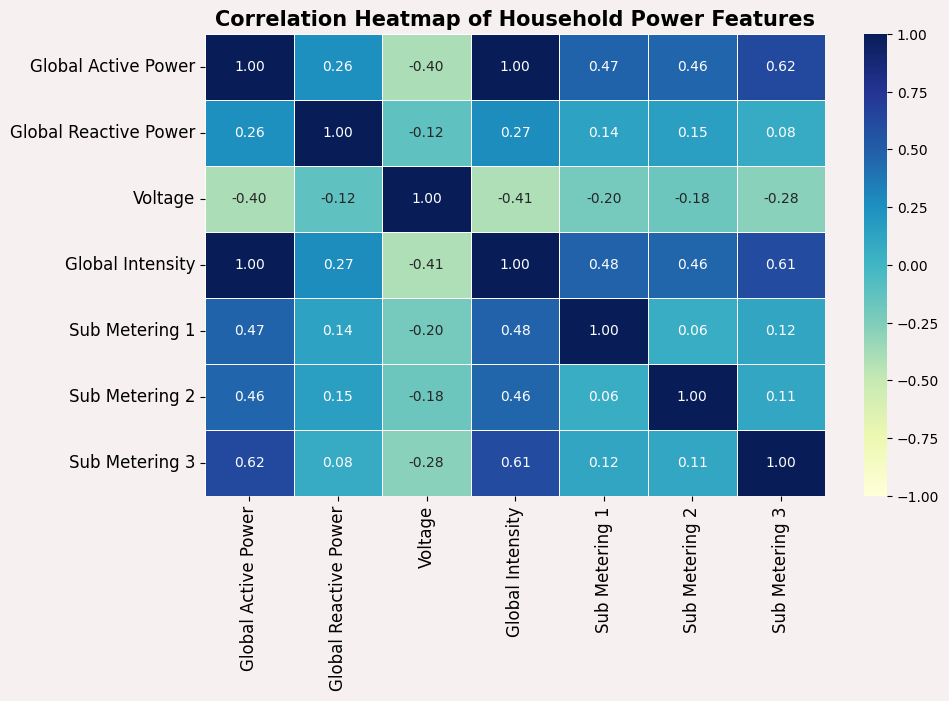

In [ ]:
# Compute correlation matrix
corr_matrix = power_consumption_data[['Global Active Power', 'Global Reactive Power', 'Voltage',
                                      'Global Intensity', 'Sub Metering 1', 'Sub Metering 2', 'Sub Metering 3']].corr()

# Plot heatmap
plt.figure(figsize=(10, 6), facecolor="#F7F0F0")
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, vmin=-1, vmax=1)

# Add title, adjust labels and tick formattings
plt.title("Correlation Heatmap of Household Power Features", fontsize=15, fontweight='bold')
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12, rotation=0)
plt.show()

The heatmap reveals a perfect positive correlation of 1.00 between Global Active Power and Global Intensity, indicating identical data density patterns. Sub Metering 3 shows the strongest sub-metering relationship with Active Power at 0.62. Voltage exhibits a negative correlation density of -0.40, suggesting power consumption slightly decreases as voltage rises.

# **Data Preprocessing**

## **Cyclical Encoding**

In [ ]:
power_consumption_data.head()

,Datetime,Global Active Power,Global Reactive Power,Voltage,Global Intensity,Sub Metering 1,Sub Metering 2,Sub Metering 3,Hour,Day,Month,Weekday,Year
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,16,12,5,2006
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,16,12,5,2006
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,16,12,5,2006
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,16,12,5,2006
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,16,12,5,2006


In [ ]:
# Apply cyclical encoding for cyclical features

# Hour
power_consumption_data['Hour_sin'] = np.sin(2*np.pi*power_consumption_data['Hour']/24)
power_consumption_data['Hour_cos'] = np.cos(2*np.pi*power_consumption_data['Hour']/24)

# Month
power_consumption_data['Month_sin'] = np.sin(2*np.pi*power_consumption_data['Month']/12)
power_consumption_data['Month_cos'] = np.cos(2*np.pi*power_consumption_data['Month']/12)

# Weekday
power_consumption_data['Weekday_sin'] = np.sin(2*np.pi*power_consumption_data['Weekday']/7)
power_consumption_data['Weekday_cos'] = np.cos(2*np.pi*power_consumption_data['Weekday']/7)

Cyclical encoding is applied to Hour, Month and Weekday using sine and cosine transformations to represent their repeating nature. This preserves the natural continuity between values such as late night and early morning or December and January. It helps machine learning models better capture periodic patterns in electricity consumption which improves pattern recognition and prediction accuracy compared to simple numerical encoding.

In [ ]:
# Drop original datetime and raw temporal features
power_consumption_data.drop(['Datetime', 'Hour', 'Day', 'Month', 'Weekday'], axis=1, inplace=True)

In [ ]:
power_consumption_data.head(3)

,Global Active Power,Global Reactive Power,Voltage,Global Intensity,Sub Metering 1,Sub Metering 2,Sub Metering 3,Year,Hour_sin,Hour_cos,Month_sin,Month_cos,Weekday_sin,Weekday_cos
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,-0.965926,-0.258819,-2.449294e-16,1.0,-0.974928,-0.222521
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006,-0.965926,-0.258819,-2.449294e-16,1.0,-0.974928,-0.222521
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006,-0.965926,-0.258819,-2.449294e-16,1.0,-0.974928,-0.222521


In [ ]:
power_consumption_data.shape

(1048575, 14)

## **Robust Scaling**

Robust Scaling is a normalisation method that centres data using the median and scales it by the interquartile range, reducing sensitivity to outliers. It is suitable for this research because power consumption features contain noise and extreme values and robust scaling preserves meaningful patterns while improving model stability and noise tolerance.


In [ ]:
# Target variable
y = power_consumption_data['Global Active Power']

# Features (numeric + cyclical)
X = power_consumption_data.drop('Global Active Power', axis=1)

In [ ]:
# Initialise RobustScaler
feature_names = X.columns
robust_scaler = RobustScaler()

# Scale features
X_robust_scaled = robust_scaler.fit_transform(X)

In [ ]:
X_robust_scaled

array([[ 1.72043011e+00, -1.29086538e+00,  3.07692308e+00, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16],
       [ 1.81720430e+00, -1.58173077e+00,  3.96153846e+00, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16],
       [ 2.15053763e+00, -1.66346154e+00,  3.96153846e+00, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16],
       ...,
       [-1.18279570e-01,  3.65384615e-01, -1.15384615e-01, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16],
       [-1.07526882e-01,  5.64903846e-01, -1.15384615e-01, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16],
       [-1.07526882e-01,  5.76923077e-01, -1.15384615e-01, ...,
         7.32050808e-01, -6.23489802e-01, -1.63861563e-16]])

In [ ]:
joblib.dump(robust_scaler, 'robust_scaler.pkl')

['robust_scaler.pkl']

In [ ]:
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_robust_scaled, y, test_size=0.2, random_state=42)

In [ ]:
X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

# **Model Building**

In [ ]:
# Different noise levels to test
# 0.05 = 5% noise
# 0.10 = 10% noise
# 0.20 = 20% noise
noise_levels = [0.05, 0.10, 0.20]

In [ ]:
def add_noise(X, noise_level):
    # Create a copy of the dataset so the original data remains unchanged
    X_noisy = X.copy()

    # List of features where noise will be injected
    # These represent sensor measurements that can be affected by noise
    noise_features = [
        'Voltage',
        'Global Intensity',
        'Sub Metering 1',
        'Sub Metering 2',
        'Sub Metering 3'
    ]

    # Loop through each selected feature
    for col in noise_features:

        # Generate Gaussian noise
        noise = np.random.normal(
            loc=0,
            scale=noise_level * X[col].std(),
            size=X.shape[0]
        )

        # Add noise to the feature
        X_noisy[col] += noise

    # Return dataset with added noise
    return X_noisy

## **Linear Regression**

Linear Regression is a statistical method that models the relationship between input features and a continuous target by fitting a straight line that minimises prediction error. It is suitable for this research because it provides a simple baseline, captures overall trends in energy data, and helps compare performance and noise sensitivity against more complex models.


In [ ]:
# Train model on clean data
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on test data
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Evaluate model performance

# Mean Absolute Error
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Root Mean Squared Error
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# R2 Score
r2_lr = r2_score(y_test, y_pred_lr)

print("-"*30)
print("<o> Linear Regression")
print("-"*30)
print(f"<o> MAE  : {mae_lr:.4f}")
print(f"<o> RMSE : {rmse_lr:.4f}")
print(f"<o> R2   : {r2_lr:.4f}")
print("-"*30)

------------------------------
<o> Linear Regression
------------------------------
<o> MAE  : 0.0266
<o> RMSE : 0.0416
<o> R2   : 0.9986
------------------------------


Linear Regression achieved very low error with MAE 0.0266 and RMSE 0.0416, while R2 reached 0.9986. Results indicate excellent predictive accuracy and a strong fit.

In [ ]:
# List to store results for each noise level
lr_noise_results = []

# Loop through each noise level
for noise in noise_levels:

    # Add noise to test data
    X_test_noisy = add_noise(X_test, noise)

    # Make predictions
    y_pred = lr_model.predict(X_test_noisy)

    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    lr_noise_results.append([noise, mae, rmse, r2])

In [ ]:
# Create a df for clean data
baseline_lr = pd.DataFrame(
    [[0, mae_lr, rmse_lr, r2_lr]],
    columns=["Noise Level", "MAE", "RMSE", "R2"]
)

# Convert a df for noisy data
results_lr_noise = pd.DataFrame(
    lr_noise_results,
    columns=["Noise Level", "MAE", "RMSE", "R2"]
)

# Combine baseline with noisy results
lr_model_results = pd.concat([baseline_lr, results_lr_noise], ignore_index=True)

# Display the updated DataFrame
lr_model_results

,Noise Level,MAE,RMSE,R2
0,0.00,0.026629,0.041618,0.998645
1,0.05,0.053607,0.070003,0.996165
2,0.10,0.095193,0.120260,0.988683
3,0.20,0.183079,0.229375,0.958831


As noise increased from 0.00 to 0.20, MAE rose from 0.0266 to 0.1831 and RMSE from 0.0416 to 0.2294, while R2 declined from 0.9986 to 0.9588. This shows performance degraded steadily with noise, though predictions remained reasonably accurate overall.


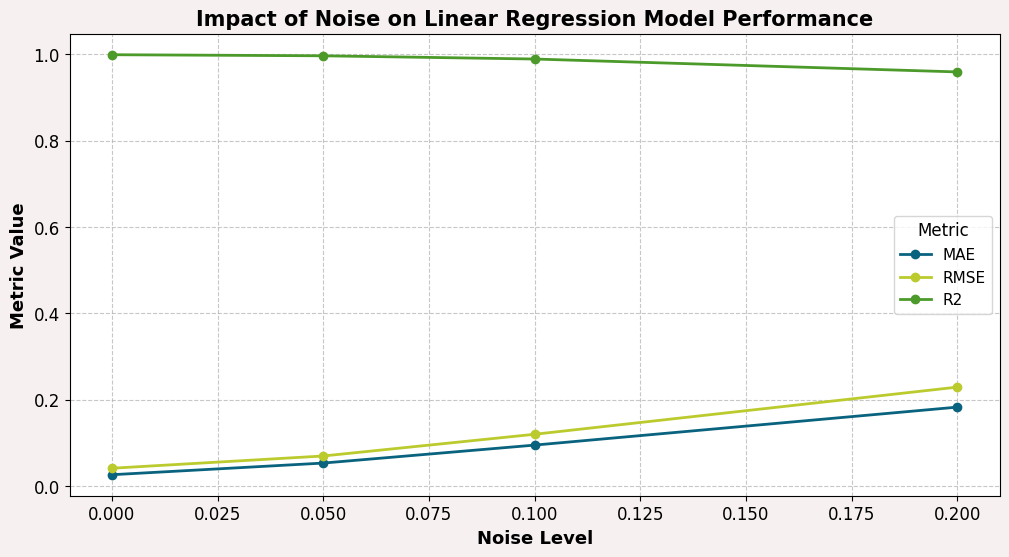

In [ ]:
# Colors for each metric
colors = {"MAE": "#09637E", "RMSE": "#BBCB2E", "R2": "#4C9A2A"}

# Plot each metric with markers and labels
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")
for metric in ["MAE", "RMSE", "R2"]:
    plt.plot(
        lr_model_results["Noise Level"],
        lr_model_results[metric],
        label=metric,
        marker='o',
        color=colors[metric],
        linewidth=2
    )

# Add title, adjust labels and tick formattings
plt.title("Impact of Noise on Linear Regression Model Performance", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("Metric Value", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(title="Metric", fontsize=11, title_fontsize=12)
plt.show()

This line graph illustrates how increasing noise levels negatively impact linear regression performance density. As noise rises from 0.000 to 0.200, the R2 score marginally declines from 1.00 to 0.96. Error density increases, with Mean Absolute Error reaching 0.18 and Root Mean Square Error ascending to 0.23.

## **Random Forest Regressor**

Random Forest Regressor is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is suitable for this research because it captures complex, non-linear relationships in energy data, handles noise effectively and provides stable predictions, making it useful for evaluating robustness under varying noise levels.


In [ ]:
# Define base model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train on training data
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)

In [ ]:
# Predictions on clean test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("-"*30)
print("<o> Random Forest")
print("-"*30)
print(f"<o> MAE  : {mae_rf:.4f}")
print(f"<o> RMSE : {rmse_rf:.4f}")
print(f"<o> R2   : {r2_rf:.4f}")
print("-"*30)

------------------------------
<o> Random Forest
------------------------------
<o> MAE  : 0.0195
<o> RMSE : 0.0351
<o> R2   : 0.9990
------------------------------


Random Forest achieved strong predictive performance with MAE 0.0195 and RMSE 0.0351, indicating low prediction error. R2 reached 0.9990, showing excellent variance explanation. Results suggest the model captured complex patterns effectively


In [ ]:
# List to store results for each noise level
rf_noise_results = []

for noise in noise_levels:
    # Add Gaussian noise to selected features
    X_test_noisy = add_noise(X_test, noise)

    # Predictions on noisy test set
    y_pred = rf_model.predict(X_test_noisy)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    rf_noise_results.append([noise, mae, rmse, r2])

In [ ]:
# Create a df for clean data
baseline_rf = pd.DataFrame(
    [[0, mae_rf, rmse_rf, r2_rf]],
    columns=["Noise Level", "MAE", "RMSE", "R2"]
)

# Convert a df for noisy data
results_rf_noise = pd.DataFrame(
    rf_noise_results,
    columns=["Noise Level", "MAE", "RMSE", "R2"]
)

# Combine baseline with noisy results
rf_model_results = pd.concat([baseline_rf, results_rf_noise], ignore_index=True)

# Display the updated DataFrame
rf_model_results

,Noise Level,MAE,RMSE,R2
0,0.00,0.019534,0.035119,0.999035
1,0.05,0.049515,0.066508,0.996539
2,0.10,0.088616,0.113983,0.989834
3,0.20,0.166194,0.212720,0.964592


Performance declined as noise increased, with MAE rising from 0.019534 to 0.166194 and RMSE from 0.035119 to 0.212720. R2 decreased from 0.999035 to 0.964592, indicating reduced accuracy. The model remained robust under moderate noise but showed noticeable degradation at higher noise levels.


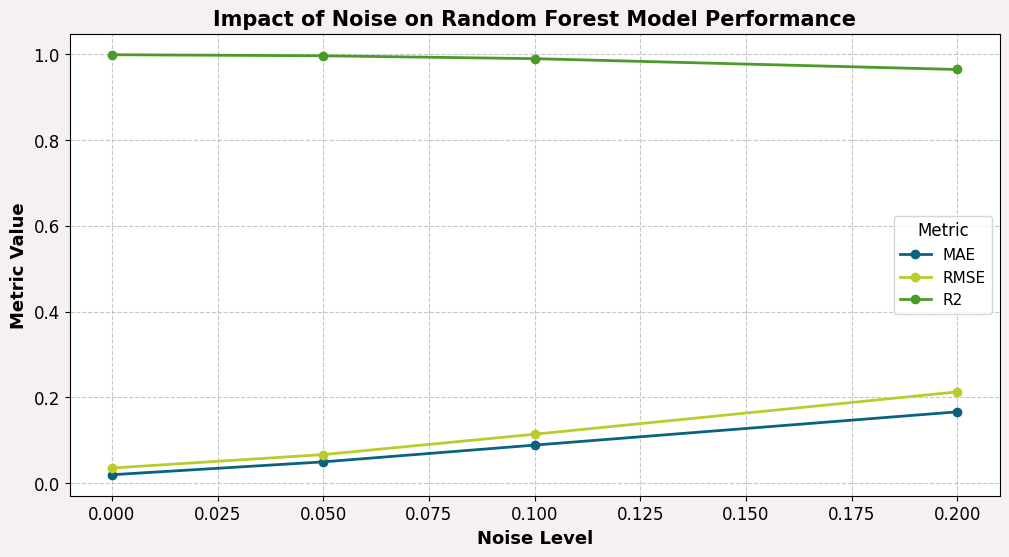

In [ ]:
# Plot each metric with markers and labels
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")
for metric in ["MAE", "RMSE", "R2"]:
    plt.plot(
        rf_model_results["Noise Level"],
        rf_model_results[metric],
        label=metric,
        marker='o',
        color=colors[metric],
        linewidth=2
    )

# Add title, adjust labels and tick formattings
plt.title("Impact of Noise on Random Forest Model Performance", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("Metric Value", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(title="Metric", fontsize=11, title_fontsize=12)
plt.show()

This line graph demonstrates how increasing noise reduces Random Forest model performance density. As noise levels rise from 0.000 to 0.200, the R2 score marginally decreases to 0.966. Simultaneously error density grows, with Mean Absolute Error reaching 0.167.

## **MLP**

MLP is a feedforward neural network consisting of multiple fully connected layers that learn complex non-linear relationships through weighted connections and activation functions. It is suitable for this research because it models intricate energy consumption patterns, achieves high predictive accuracy, and adapts well to scaled data, enabling robust performance evaluation under noisy conditions.


In [ ]:
# Simple feedforward neural network
mlp_model = Sequential([

    # Hidden layer 1 (with input dimension)
    Dense(256, activation='relu', input_dim=X_train.shape[1]),

    # Hidden layer 2
    Dense(128, activation='relu'),

    # Hidden layer 3
    Dense(128, activation='relu'),

    # Hidden layer 4
    Dense(64, activation='relu'),

    # Hidden layer 5
    Dense(64, activation='relu'),

    # Hidden layer 6
    Dense(32, activation='relu'),

    # Hidden layer 7
    Dense(32, activation='relu'),

    # Hidden layer 8
    Dense(16, activation='relu'),

    # Output layer
    Dense(1)
])

# Compile model
mlp_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Summary to check layers and parameters
mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,089 (269.88 KB)

 Trainable params: 69,089 (269.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
hist_mlp = mlp_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    verbose=2
)

Epoch 1/10
1475/1475 - 11s - 8ms/step - loss: 0.0264 - mae: 0.0466 - val_loss: 0.0012 - val_mae: 0.0218
Epoch 2/10
1475/1475 - 5s - 3ms/step - loss: 0.0017 - mae: 0.0245 - val_loss: 0.0012 - val_mae: 0.0212
Epoch 3/10
1475/1475 - 4s - 3ms/step - loss: 0.0015 - mae: 0.0230 - val_loss: 0.0026 - val_mae: 0.0322
Epoch 4/10
1475/1475 - 4s - 3ms/step - loss: 0.0013 - mae: 0.0217 - val_loss: 0.0011 - val_mae: 0.0197
Epoch 5/10
1475/1475 - 5s - 3ms/step - loss: 0.0013 - mae: 0.0216 - val_loss: 0.0011 - val_mae: 0.0199
Epoch 6/10
1475/1475 - 4s - 3ms/step - loss: 0.0013 - mae: 0.0213 - val_loss: 9.3367e-04 - val_mae: 0.0177
Epoch 7/10
1475/1475 - 4s - 3ms/step - loss: 0.0011 - mae: 0.0199 - val_loss: 0.0016 - val_mae: 0.0220
Epoch 8/10
1475/1475 - 4s - 3ms/step - loss: 0.0011 - mae: 0.0198 - val_loss: 9.3876e-04 - val_mae: 0.0177
Epoch 9/10
1475/1475 - 4s - 3ms/step - loss: 0.0011 - mae: 0.0196 - val_loss: 8.6501e-04 - val_mae: 0.0177
Epoch 10/10
1475/1475 - 5s - 3ms/step - loss: 0.0010 - mae: 

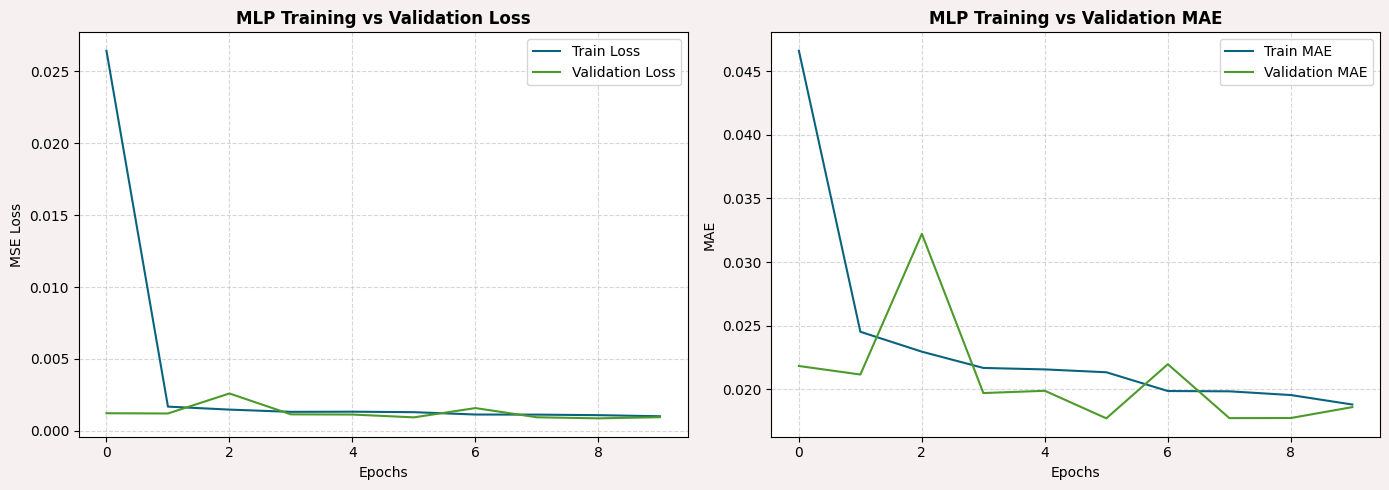

In [ ]:
# Plot learning curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F7F0F0")

# Training & validation loss
axes[0].plot(hist_mlp.history['loss'], label='Train Loss', color='#09637E')
axes[0].plot(hist_mlp.history['val_loss'], label='Validation Loss', color='#4C9A2A')
axes[0].set_title("MLP Training vs Validation Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Training & validation MAE
axes[1].plot(hist_mlp.history['mae'], label='Train MAE', color='#09637E')
axes[1].plot(hist_mlp.history['val_mae'], label='Validation MAE', color='#4C9A2A')
axes[1].set_title("MLP Training vs Validation MAE", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

This learning curve illustrate MLP training and validation performance over 10 epochs. MSE loss density drops sharply from 0.026 to near 0.001. MAE density converges similarly, with validation error stabilising around 0.018, showing consistent model learning.

In [ ]:
# Predictions on clean test data
y_pred_mlp = mlp_model.predict(X_test).flatten()

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


In [ ]:
# Evaluate model performance
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("-"*30)
print("<o> MLP")
print("-"*30)
print(f"<o> MAE  : {mae_mlp:.4f}")
print(f"<o> RMSE : {rmse_mlp:.4f}")
print(f"<o> R2   : {r2_mlp:.4f}")
print("-"*30)

------------------------------
<o> MLP
------------------------------
<o> MAE  : 0.0188
<o> RMSE : 0.0313
<o> R2   : 0.9992
------------------------------


The MLP achieved strong predictive accuracy, with MAE of 0.0188 and RMSE of 0.0313, alongside an R2 of 0.9992. These results indicate excellent model fit and minimal error, demonstrating that the model captured underlying patterns effectively and produced highly reliable predictions.


In [ ]:
# List to store results for each noise level
mlp_noise_results = []

for noise in noise_levels:
    # Add Gaussian noise to selected features
    X_test_noisy = add_noise(X_test, noise)

    # Predictions on noisy test set
    y_pred_noisy = mlp_model.predict(X_test_noisy)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred_noisy)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_noisy))
    r2 = r2_score(y_test, y_pred_noisy)

    # Store results
    mlp_noise_results.append([noise, mae, rmse, r2])

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [ ]:
# Create a df for clean data
baseline_mlp = pd.DataFrame([[0, mae_mlp, rmse_mlp, r2_mlp]],
                            columns=["Noise Level", "MAE", "RMSE", "R2"]
                            )

# Convert a df for noisy data
results_mlp_noise = pd.DataFrame(mlp_noise_results,
                                 columns=["Noise Level", "MAE", "RMSE", "R2"]
                                 )

# Combine baseline with noisy results
mlp_model_results = pd.concat([baseline_mlp, results_mlp_noise], ignore_index=True)

# Display the updated DataFrame
mlp_model_results

,Noise Level,MAE,RMSE,R2
0,0.00,0.018765,0.031304,0.999233
1,0.05,0.044727,0.060188,0.997165
2,0.10,0.081830,0.106793,0.991076
3,0.20,0.155493,0.202651,0.967865


As noise increased from 0.00 to 0.20, MAE rose from 0.018765 to 0.155493 and RMSE from 0.031304 to 0.202651, while R2 declined from 0.999233 to 0.967865. This indicates reduced prediction accuracy and model stability under higher noise conditions, though performance remained relatively strong overall.


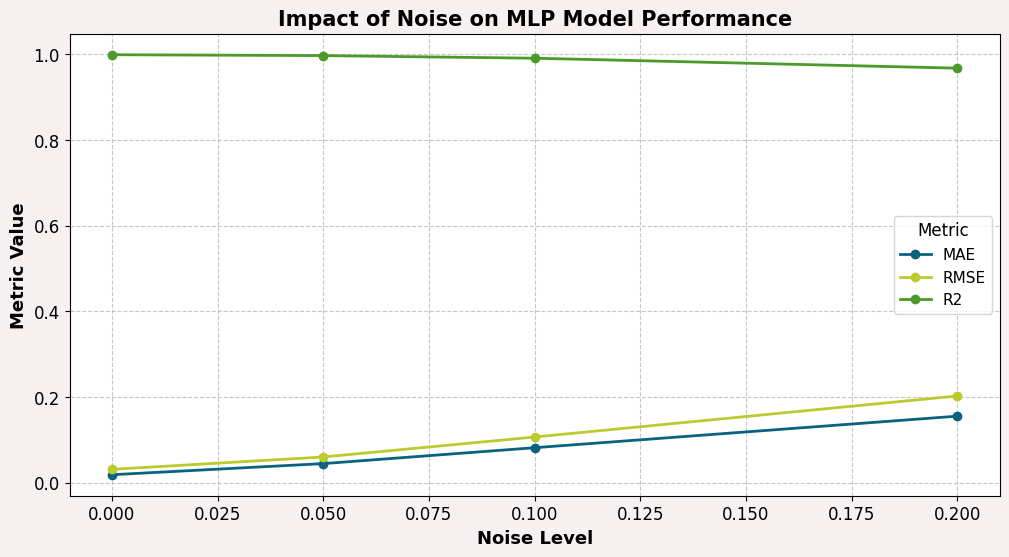

In [ ]:
# Plot each metric with markers and labels
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")
for metric in ["MAE", "RMSE", "R2"]:
    plt.plot(
        mlp_model_results["Noise Level"],
        mlp_model_results[metric],
        label=metric,
        marker='o',
        color=colors[metric],
        linewidth=2
    )

# Add title, adjust labels and tick formattings
plt.title("Impact of Noise on MLP Model Performance", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("Metric Value", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(title="Metric", fontsize=11, title_fontsize=12)
plt.show()

This line graph demonstrates how increasing noise reduces MLP model performance density. As noise levels rise from 0.000 to 0.200, the R2 score marginally decreases to 0.968. Simultaneously error density grows, with Mean Absolute Error reaching 0.156.

In [ ]:
mlp_model.save('mlp_power_model.keras')

## **CNN**

CNN is a deep learning model that uses convolutional layers to automatically extract patterns and hierarchical features from structured data. It is suitable for this research because it captures complex temporal and feature interactions, improves prediction accuracy and remains effective under noisy conditions.


In [ ]:
# Reshape input for Conv1D
X_train_cnn = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_cnn = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

In [ ]:
# Define Conv1D model
input_shape = (X_train_cnn.shape[1], X_train_cnn.shape[2])

# Input layer
inputs = Input(shape=input_shape)

# Convolutional block 1
x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

# Convolutional block 2
x = Conv1D(filters=32, kernel_size=1, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.1)(x)

# Attention block
attn_output = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)  # Self-attention
x = Add()([x, attn_output])  # Residual connection
x = LayerNormalization()(x)

# Flatten and Dense layers
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.1)(x)
x = Dense(32, activation='relu')(x)

# Output layer
outputs = Dense(1)(x)

# Define model
cnn_model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [ ]:
# Summary to check layers and parameters
cnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1, 13)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 64)     │        896 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1, 64)     │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 32)     │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 32)     │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1, 32)     │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 32)     │      8,416 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 32)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 64)        │      2,112 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 1)         │         33 │ dense_29[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,065 (62.75 KB)

 Trainable params: 15,873 (62.00 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [ ]:
# Train the model
hist_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=512,
    verbose=2
)

Epoch 1/10
1475/1475 - 20s - 13ms/step - loss: 0.0779 - mae: 0.1505 - val_loss: 0.0088 - val_mae: 0.0667
Epoch 2/10
1475/1475 - 5s - 3ms/step - loss: 0.0224 - mae: 0.0854 - val_loss: 0.0220 - val_mae: 0.0971
Epoch 3/10
1475/1475 - 5s - 4ms/step - loss: 0.0166 - mae: 0.0723 - val_loss: 0.0445 - val_mae: 0.1304
Epoch 4/10
1475/1475 - 5s - 3ms/step - loss: 0.0138 - mae: 0.0662 - val_loss: 0.0187 - val_mae: 0.0896
Epoch 5/10
1475/1475 - 5s - 3ms/step - loss: 0.0121 - mae: 0.0623 - val_loss: 0.0156 - val_mae: 0.0702
Epoch 6/10
1475/1475 - 5s - 3ms/step - loss: 0.0108 - mae: 0.0589 - val_loss: 0.0211 - val_mae: 0.0828
Epoch 7/10
1475/1475 - 5s - 3ms/step - loss: 0.0100 - mae: 0.0571 - val_loss: 0.0206 - val_mae: 0.0755
Epoch 8/10
1475/1475 - 5s - 4ms/step - loss: 0.0089 - mae: 0.0542 - val_loss: 0.0123 - val_mae: 0.0613
Epoch 9/10
1475/1475 - 5s - 3ms/step - loss: 0.0084 - mae: 0.0530 - val_loss: 0.0088 - val_mae: 0.0536
Epoch 10/10
1475/1475 - 5s - 3ms/step - loss: 0.0077 - mae: 0.0511 - va

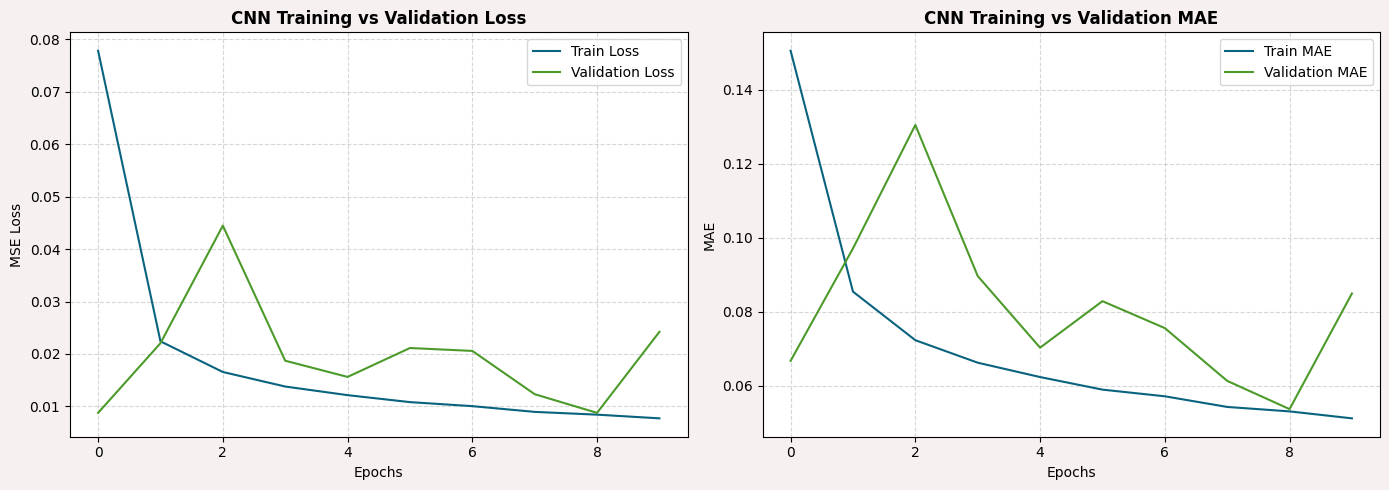

In [ ]:
# Plot CNN learning curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#F7F0F0")

# Training & validation loss
axes[0].plot(hist_cnn.history['loss'], label='Train Loss', color='#09637E')
axes[0].plot(hist_cnn.history['val_loss'], label='Validation Loss', color='#4C9A2A')
axes[0].set_title("CNN Training vs Validation Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Training & validation MAE
axes[1].plot(hist_cnn.history['mae'], label='Train MAE', color='#09637E')
axes[1].plot(hist_cnn.history['val_mae'], label='Validation MAE', color='#4C9A2A')
axes[1].set_title("CNN Training vs Validation MAE", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

These learning curves illustrate CNN training and validation performance over ten epochs. MSE loss density drops from 0.078 to approximately 0.008. MAE density fluctuates significantly, with validation error peaking near 0.130 before concluding at 0.085.

In [ ]:
# Evaluate model performance
y_pred_cnn = cnn_model.predict(X_test_cnn)
mae_cnn = mean_absolute_error(y_test, y_pred_cnn)
rmse_cnn = np.sqrt(mean_squared_error(y_test, y_pred_cnn))
r2_cnn = r2_score(y_test, y_pred_cnn)

print("-"*30)
print("<o> Conv1D ")
print("-"*30)
print(f"<o> MAE  : {mae_cnn:.4f}")
print(f"<o> RMSE : {rmse_cnn:.4f}")
print(f"<o> R2   : {r2_cnn:.4f}")
print("-"*30)

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
------------------------------
<o> Conv1D 
------------------------------
<o> MAE  : 0.0853
<o> RMSE : 0.1561
<o> R2   : 0.9809
------------------------------


Conv1D achieved MAE 0.0853 and RMSE 0.1561 with R2 0.9809 which indicates good predictive capability but lower accuracy than other models. Higher error values suggest reduced precision, though the model still captured overall consumption patterns effectively.


In [ ]:
# List to store results for each noise level
cnn_noise_results = []

# Add Gaussian noise to selected features
for noise in noise_levels:
    X_test_noisy = add_noise(X_test, noise).values.reshape(X_test.shape[0], 1, X_test.shape[1])

    # Predictions on noisy test set
    y_pred = cnn_model.predict(X_test_noisy)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    cnn_noise_results.append([noise, mae, rmse, r2])

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [ ]:
# Results dataframe
baseline_cnn = pd.DataFrame([[0, mae_cnn, rmse_cnn, r2_cnn]], columns=["Noise Level", "MAE", "RMSE", "R2"])
results_cnn_noise = pd.DataFrame(cnn_noise_results, columns=["Noise Level", "MAE", "RMSE", "R2"])
cnn_model_results = pd.concat([baseline_cnn, results_cnn_noise], ignore_index=True)

# Display results
cnn_model_results

,Noise Level,MAE,RMSE,R2
0,0.00,0.085323,0.156078,0.980938
1,0.05,0.098743,0.162989,0.979213
2,0.10,0.123963,0.182462,0.973949
3,0.20,0.181346,0.242900,0.953833


Conv1D performance declined steadily as noise increased. MAE rose from 0.0853 to 0.1813 and RMSE from 0.1561 to 0.2429, while R2 dropped from 0.9809 to 0.9538. The model remained functional but showed greater sensitivity to noise than other approaches.


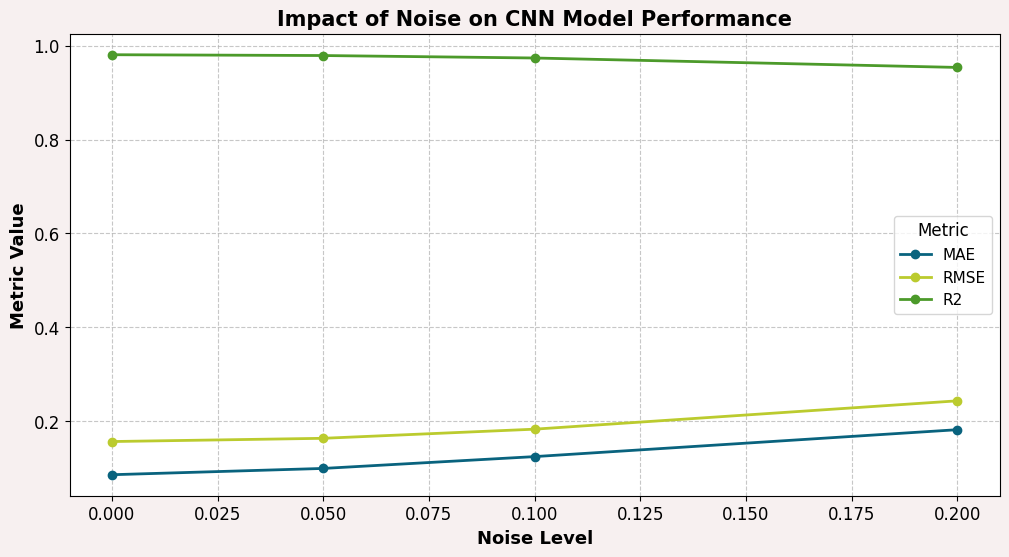

In [ ]:
# Plot each metric with markers and labels
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")
for metric in ["MAE", "RMSE", "R2"]:
    plt.plot(
        cnn_model_results["Noise Level"],
        cnn_model_results[metric],
        label=metric,
        marker='o',
        color=colors[metric],
        linewidth=2
    )

# Add title, adjust labels and tick formattings
plt.title("Impact of Noise on CNN Model Performance", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("Metric Value", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Add legend
plt.legend(title="Metric", fontsize=11, title_fontsize=12)
plt.show()

The line graph illustrates how increasing noise reduces CNN model performance density. As noise levels rise from 0.000 to 0.200, the R2 score marginally decreases to 0.954. Simultaneously error density grows, with Mean Absolute Error reaching 0.181.

# **Comparative Analysis**

In [ ]:
# Add a 'Model' column to each results df
lr_model_results['Model'] = 'Linear Regression'
rf_model_results['Model'] = 'Random Forest'
mlp_model_results['Model'] = 'MLP'
cnn_model_results['Model'] = 'CNN'

# Concatenate all DataFrames
all_models_results = pd.concat(
    [lr_model_results, rf_model_results, mlp_model_results, cnn_model_results],
    ignore_index=True
)

# Reorder columns for clarity
all_models_results = all_models_results[['Model', 'Noise Level', 'MAE', 'RMSE', 'R2']]

# Display combined results
all_models_results.head(16)

,Model,Noise Level,MAE,RMSE,R2
0,Linear Regression,0.00,0.026629,0.041618,0.998645
1,Linear Regression,0.05,0.053607,0.070003,0.996165
2,Linear Regression,0.10,0.095193,0.120260,0.988683
3,Linear Regression,0.20,0.183079,0.229375,0.958831
4,Random Forest,0.00,0.019534,0.035119,0.999035
5,Random Forest,0.05,0.049515,0.066508,0.996539
6,Random Forest,0.10,0.088616,0.113983,0.989834
7,Random Forest,0.20,0.166194,0.212720,0.964592
8,MLP,0.00,0.018765,0.031304,0.999233
9,MLP,0.05,0.044727,0.060188,0.997165


In [ ]:
# Save the combined results to CSV
all_models_results.to_csv("all_models_results.csv", index=False)

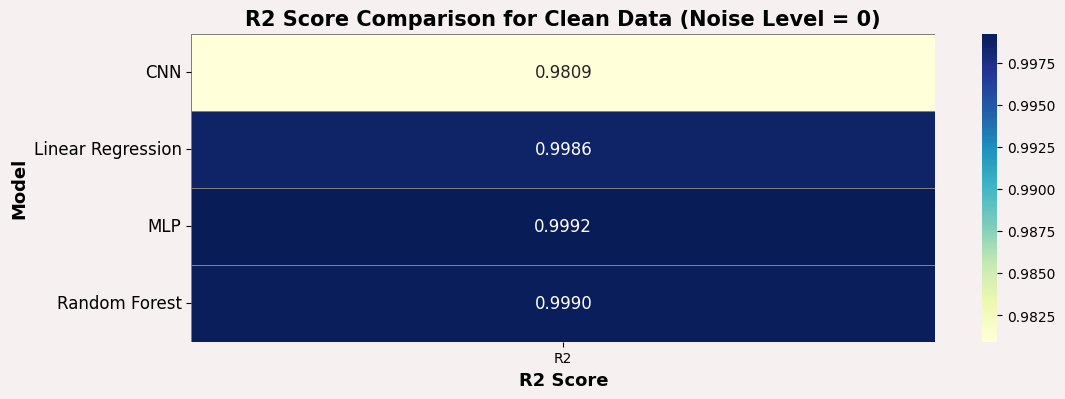

In [ ]:
# Filter results received from models trained on clean data
clean_data_r2 = all_models_results[all_models_results['Noise Level'] == 0]

# Prepare data for heatmap
heatmap_data = clean_data_r2.pivot_table(index='Model', values='R2')

# Plot heatmap
plt.figure(figsize=(12, 4), facecolor="#F7F0F0")
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="YlGnBu",
    cbar=True, linewidths=0.5, linecolor='gray', annot_kws={"size": 12})

# Add title, adjust labels and tick formattings
plt.title("R2 Score Comparison for Clean Data (Noise Level = 0)", fontsize=15, fontweight='bold')
plt.ylabel("Model", fontsize=13, fontweight='bold')
plt.xlabel("R2 Score", fontsize=13, fontweight='bold')
plt.yticks(rotation=0, fontsize=12)
plt.show()

The heatmap compares predictive accuracy for clean data, showing high performance density across most models. MLP achieves the peak R2 score of 0.9992, closely followed by Random Forest at 0.9990. CNN displays the lowest density at 0.9809.

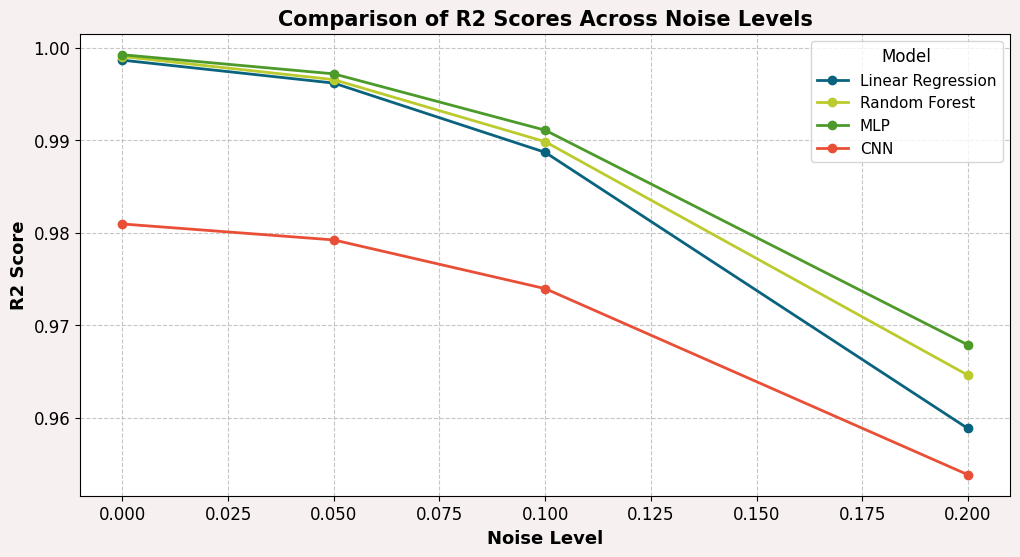

In [ ]:
# Set figure
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")

# Define colors for each model
colors = {
    "Linear Regression": "#09637E",
    "Random Forest": "#BBCB2E",
    "MLP": "#4C9A2A",
    "CNN": "#E94F37"
}

# Plot R2 for each model
for model in all_models_results['Model'].unique():
    df_model = all_models_results[all_models_results['Model'] == model]
    plt.plot(df_model['Noise Level'], df_model['R2'], marker='o', linewidth=2, label=model, color=colors[model])

# Add title, adjust labels and tick formattings
plt.title("Comparison of R2 Scores Across Noise Levels", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("R2 Score", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(title="Model", fontsize=11, title_fontsize=12)
plt.show()

This line graph compares R2 score density across four models as noise increases. The MLP model maintains the highest performance density, ending at 0.968, whereas the CNN model consistently displays the lowest density, dropping to 0.954 at the 0.200 noise level.

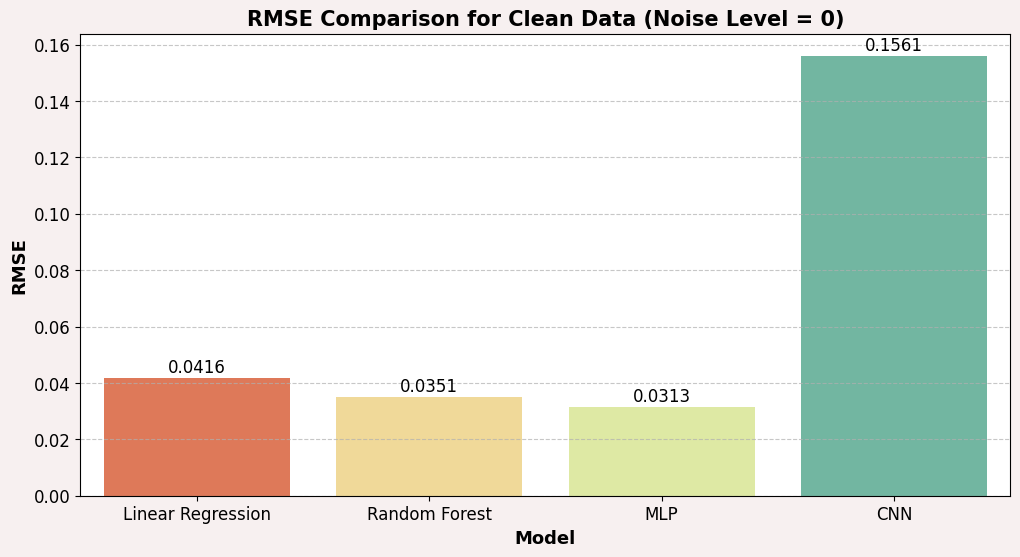

In [ ]:
# Filter clean data (Noise Level = 0)
clean_data = all_models_results[all_models_results['Noise Level'] == 0]

# Prepare figure
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")

# Bar plot
sns.barplot(x='Model', y='RMSE', data=clean_data, palette="Spectral", hue = 'Model')

# Add title, adjust labels and tick formattings
plt.title("RMSE Comparison for Clean Data (Noise Level = 0)", fontsize=15, fontweight='bold')
plt.xlabel("Model", fontsize=13, fontweight='bold')
plt.ylabel("RMSE", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Annotate bars
for i, v in enumerate(clean_data['RMSE']):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center', fontsize=12)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart highlights performance density through Root Mean Square Error on clean data. The MLP model achieves the highest accuracy with a minimal error density of 0.0313. The CNN model exhibits significantly lower precision with a peak error value of 0.1561.

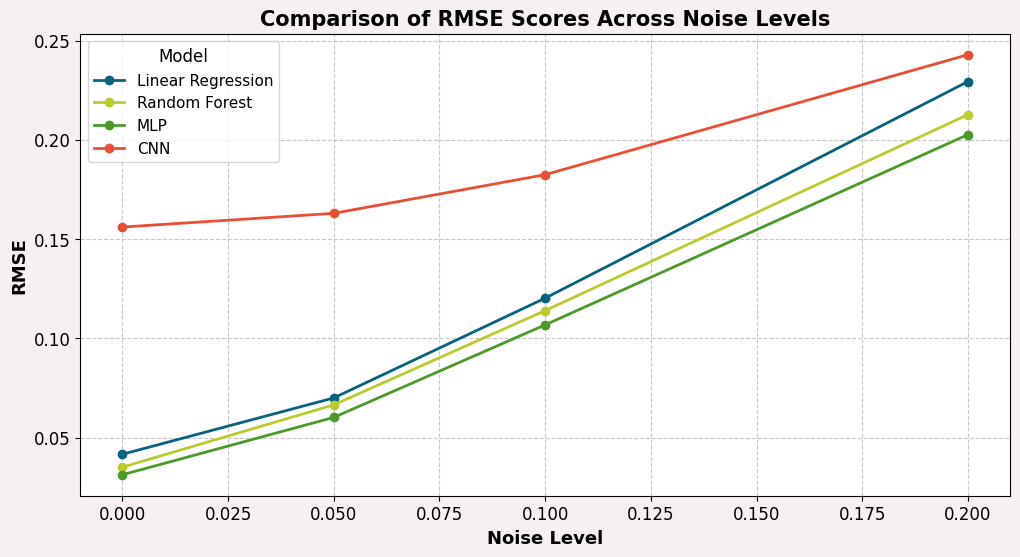

In [ ]:
# Prepare figure
plt.figure(figsize=(12,6), facecolor="#F7F0F0")

# Plot RMSE for each model across noise levels
for model in all_models_results['Model'].unique():
    subset = all_models_results[all_models_results['Model'] == model]
    plt.plot(subset['Noise Level'], subset['RMSE'], marker='o', label=model, color=colors[model], linewidth=2)

# Add title, adjust labels and tick formattings
plt.title("Comparison of RMSE Scores Across Noise Levels", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("RMSE", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(title="Model", fontsize=11, title_fontsize=12)
plt.show()

The line graph compares RMSE across four models as noise increases. The MLP model maintains the lowest error density, ending at 0.2025, while the CNN model consistently displays the highest error density, reaching 0.2429 at the 0.200 noise level.

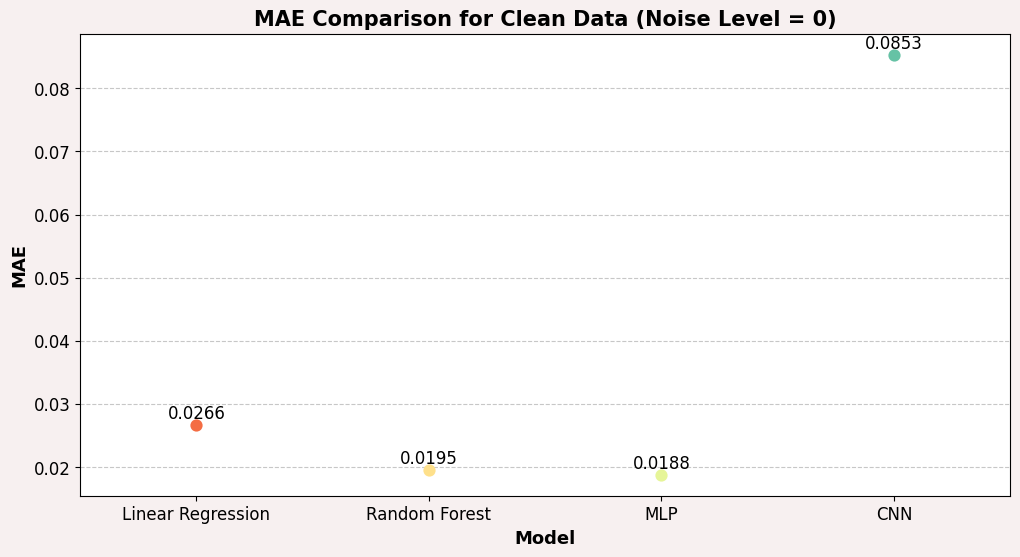

In [ ]:
# Filter clean data (Noise Level = 0)
clean_mae = all_models_results[all_models_results['Noise Level'] == 0]

# Plot pointplot
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")
sns.pointplot(x='Model', y='MAE', data=clean_mae, markers='o', linestyles='-', capsize=0.1, palette="Spectral", hue='Model')

# Add title, adjust labels and tick formattings
plt.title("MAE Comparison for Clean Data (Noise Level = 0)", fontsize=15, fontweight='bold')
plt.xlabel("Model", fontsize=13, fontweight='bold')
plt.ylabel("MAE", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate points
for i, v in enumerate(clean_mae['MAE']):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontsize=12)
plt.show()

Above dot plot highlights Mean Absolute Error density for clean data across four models. The MLP model achieves the lowest error density at 0.0188. In contrast the CNN model exhibits the highest error, reaching a value of 0.0853.

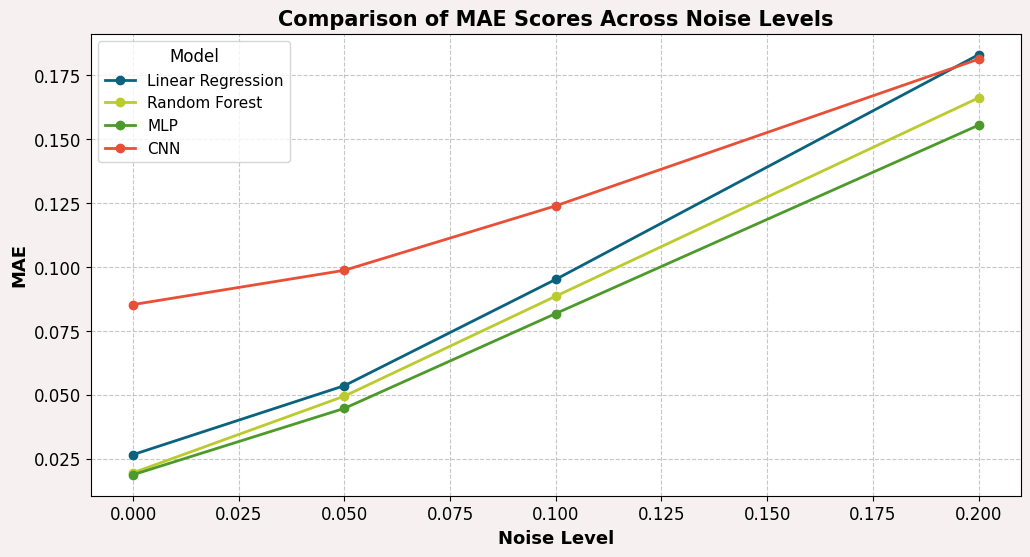

In [ ]:
# Prepare figure
plt.figure(figsize=(12, 6), facecolor="#F7F0F0")

# Plot MAE for each model across noise levels
for model in all_models_results['Model'].unique():
    subset = all_models_results[all_models_results['Model'] == model]
    plt.plot(subset['Noise Level'], subset['MAE'], marker='o', label=model, color=colors[model], linewidth=2)

# Add title, adjust labels and tick formattings
plt.title("Comparison of MAE Scores Across Noise Levels", fontsize=15, fontweight='bold')
plt.xlabel("Noise Level", fontsize=13, fontweight='bold')
plt.ylabel("MAE", fontsize=13, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(title="Model", fontsize=11, title_fontsize=12)
plt.show()

This line graph compares Mean Absolute Error density across four models as noise levels increase. The MLP model maintains the lowest error density, ending at 0.1555, while Linear Regression and CNN both reach a peak error of around 0.1824.


# **Explainability Analysis**

LIME (Local Interpretable Model-agnostic Explanations) is an explainability technique that interprets complex machine learning models. It is suitable for this research because it explains individual predictions, highlights important features affecting energy consumption, and improves model transparency, helping users understand and trust results.

## **Linear Regression**

In [ ]:
# Create LIME explainer

# LIME explainer learns the distribution of the training data
# and generates local perturbations around a sample to explain predictions
lr_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    verbose=False
)

In [ ]:
# Custom prediction function
# LIME passes numpy arrays, but the model expects df with column names
def lr_predict_fn(x):
    return lr_model.predict(
        pd.DataFrame(x, columns=X_train.columns)
    )

# Select a single test instance to explain
sample_idx = 10

In [ ]:
# Noise levels to test explanation stability
noise_levels = [0, 0.05, 0.10, 0.20]

# List to store explanations for each noise level
explanations = []

In [ ]:
# Generate LIME explanations

# Loop through each noise level
for noise in noise_levels:

    # Add Gaussian noise to the test dataset, skip noise addition for clean data (noise = 0)
    if noise == 0:
        X_temp = X_test.copy()
    else:
        X_temp = X_test + noise * np.random.normal(size=X_test.shape)

    # Select the same sample under noisy conditions
    sample_temp = X_temp.iloc[sample_idx].values

    # Generate LIME explanation for the sample
    exp_temp = lr_explainer.explain_instance(
        sample_temp,         # Instance to explain
        lr_predict_fn,       # Prediction function
        num_features=13       # Number of features to include in explanation
    )

    # Store explanation with corresponding noise level
    explanations.append((noise, exp_temp))

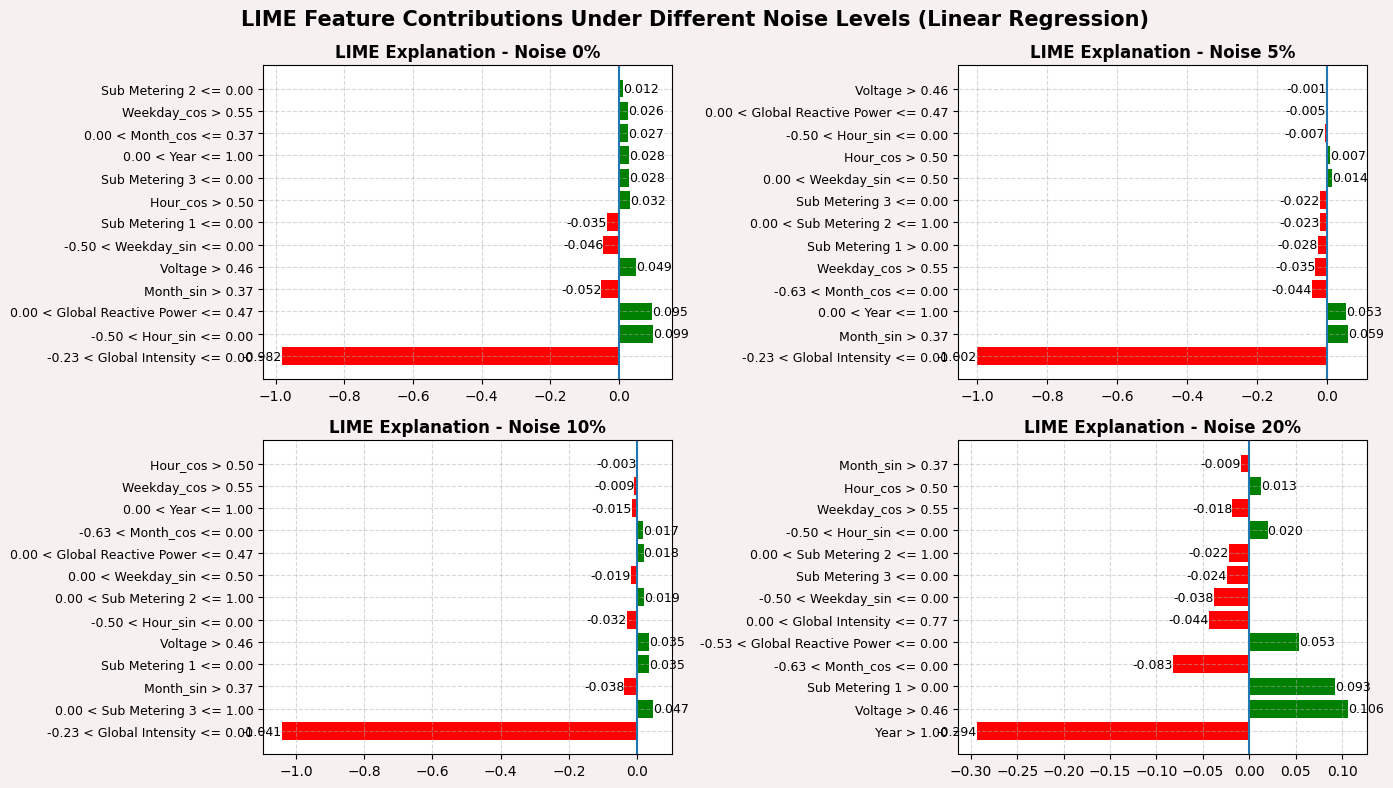

In [ ]:
# Plot LIME explanations

# Create a 2x2 grid for visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor="#F7F0F0")
axes = axes.flatten()

# Plot explanation for each noise level
for i, (noise, exp) in enumerate(explanations):

    # Extract feature names and contribution values
    features = [f[0] for f in exp.as_list()]
    values = [f[1] for f in exp.as_list()]

    # LIME color scheme:
    # Green : positive contribution
    # Red : negative contribution
    colors = ['green' if v > 0 else 'red' for v in values]

    # Create horizontal bar plot
    bars = axes[i].barh(features, values, color=colors)

    # Add numeric contribution values as annotations
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left' if width > 0 else 'right', fontsize=9)

    # Plot formatting
    axes[i].set_title(
        f"LIME Explanation - Noise {int(noise*100)}%", fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].axvline(0)

# Add overall title
plt.suptitle(
    "LIME Feature Contributions Under Different Noise Levels (Linear Regression)",
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

LIME explanations of linear regression model shows that Global Intensity as the dominant feature under clean and low noise conditions, with strong negative contributions near −0.98 to −1.04, indicating stable influence. Temporal features such as Hour and Month show moderate but fluctuating contributions. As noise increases, feature importance becomes less consistent, with Year, Voltage and Sub Metering 1 gaining influence at higher noise levels. At 20% noise, Global Intensity loses dominance and Year becomes strongly negative near −0.29, indicating instability. Sub Metering 2, Sub Metering 3, and cyclical features such as Hour_sin and Weekday_sin show inconsistent contributions, suggesting they are potentially unreliable under noisy conditions.


In [ ]:
# Print contribution values for each noise level
print("\n" + "="*55)
print("LIME Feature Contributions at Different Noise Levels")
print("="*55)
for noise, exp in explanations:
    print(f"\nNoise Level: {int(noise*100)}%")
    print("-"*45)

    # Print each feature contribution
    for feature, value in exp.as_list():
        print(f"{feature:30s}: {value:.4f}")


LIME Feature Contributions at Different Noise Levels

Noise Level: 0%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -0.9821
-0.50 < Hour_sin <= 0.00      : 0.0992
0.00 < Global Reactive Power <= 0.47: 0.0951
Month_sin > 0.37              : -0.0519
Voltage > 0.46                : 0.0491
-0.50 < Weekday_sin <= 0.00   : -0.0464
Sub Metering 1 <= 0.00        : -0.0352
Hour_cos > 0.50               : 0.0317
Sub Metering 3 <= 0.00        : 0.0283
0.00 < Year <= 1.00           : 0.0276
0.00 < Month_cos <= 0.37      : 0.0267
Weekday_cos > 0.55            : 0.0264
Sub Metering 2 <= 0.00        : 0.0119

Noise Level: 5%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -1.0017
Month_sin > 0.37              : 0.0587
0.00 < Year <= 1.00           : 0.0531
-0.63 < Month_cos <= 0.00     : -0.0440
Weekday_cos > 0.55            : -0.0346
Sub Metering 1 > 0.00         : -0.0276
0.00 < Sub Metering 2 <= 1.00 : -0.0225
Sub Metering 3 <= 0.0

## **Random Forest**

In [ ]:
# Create LIME explainer

# LIME learns the distribution of the training data
# and generates local perturbations to explain predictions
rf_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    verbose=False
)

In [ ]:
# Custom prediction function
# LIME passes numpy arrays but the model expects a df
def rf_predict_fn(x):
    return rf_model.predict(
        pd.DataFrame(x, columns=X_train.columns)
    )

In [ ]:
# List to store explanations
explanations_rf = []

# Generate LIME explanations

# Loop through each noise level
for noise in noise_levels:

    # Add Gaussian noise (skip for clean data)
    if noise == 0:
        X_temp = X_test.copy()
    else:
        X_temp = X_test + noise * np.random.normal(size=X_test.shape)

    # Select same sample
    sample_temp = X_temp.iloc[sample_idx].values

    # Generate explanation
    exp_temp = rf_explainer.explain_instance(
        sample_temp,
        rf_predict_fn,
        num_features=13
    )

    explanations_rf.append((noise, exp_temp))

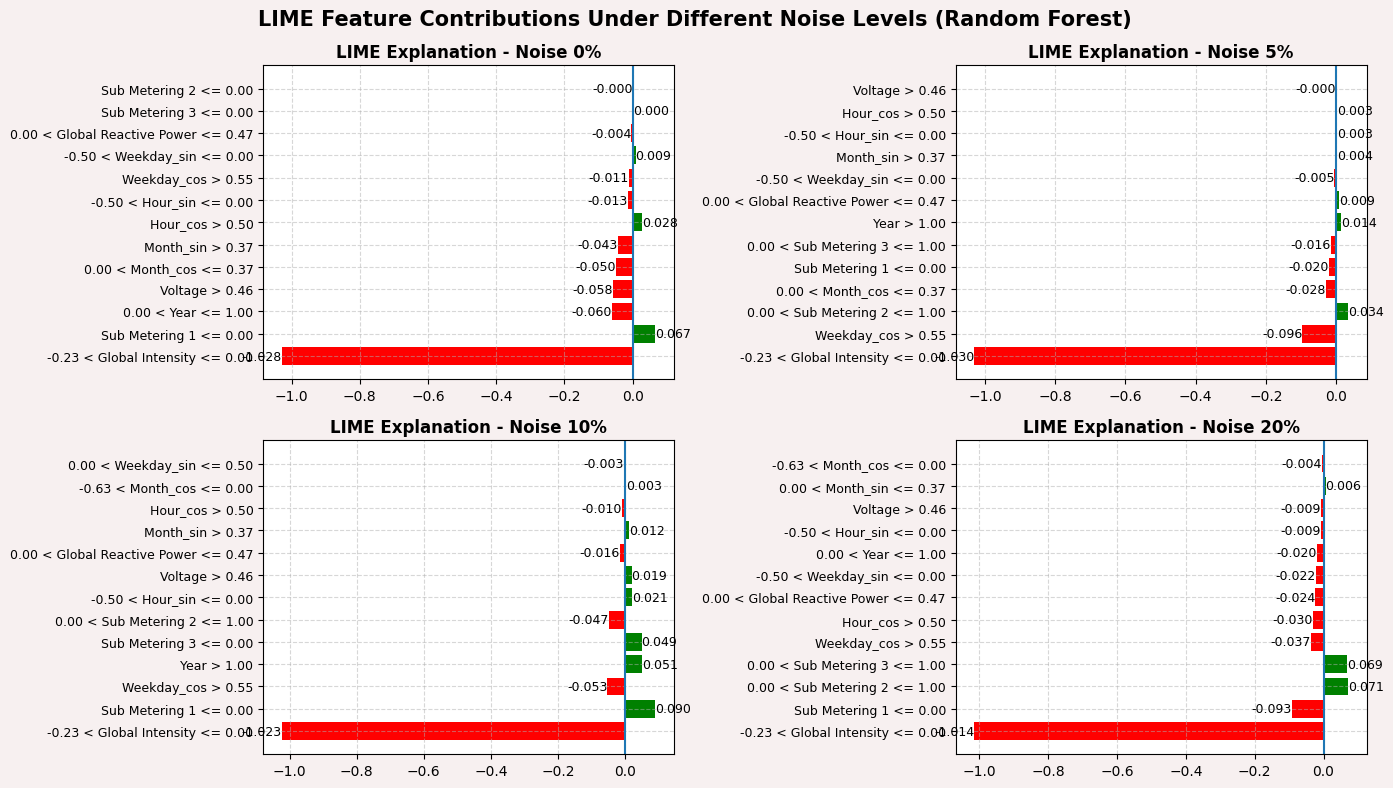

In [ ]:
# Plot LIME explanations

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor="#F7F0F0")
axes = axes.flatten()

for i, (noise, exp) in enumerate(explanations_rf):
    # Extract feature contributions
    features = [f[0] for f in exp.as_list()]
    values = [f[1] for f in exp.as_list()]

    # LIME colors
    colors = ['green' if v > 0 else 'red' for v in values]

    # Horizontal bar plot
    bars = axes[i].barh(features, values, color=colors)

    # Add contribution values
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left' if width > 0 else 'right', fontsize=9)

    # Formatting
    axes[i].set_title(
        f"LIME Explanation - Noise {int(noise*100)}%",
        fontsize=12,
        fontweight='bold'
    )
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].axvline(0)

# Overall title
plt.suptitle("LIME Feature Contributions Under Different Noise Levels (Random Forest)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

LIME results for the RF model show Global Intensity consistently dominates feature influence, with strong negative contributions around -1.02 to -1.03 across all noise levels, indicating stable importance. At zero noise, Voltage near −0.06 and Year near −0.06 have moderate effects. With 5 to 10% noise, Weekday_cos reaches about −0.10 and Sub Metering 1 rises near 0.09, showing increased variability. At 20% noise, Sub Metering 2 near 0.07 and Sub Metering 3 near 0.07 become more influential, while Sub Metering 1 shifts to about −0.09. Hour_sin, Month_cos and Weekday_sin remain weak and inconsistent, suggesting they are potentially unreliable under noisy conditions.


In [ ]:
# Print contribution values for each noise level
print("\n" + "="*55)
print("LIME Feature Contributions at Different Noise Levels")
print("="*55)
for noise, exp in explanations_rf:
    print(f"\nNoise Level: {int(noise*100)}%")
    print("-"*45)

    # Print each feature contribution
    for feature, value in exp.as_list():
        print(f"{feature:30s}: {value:.4f}")


LIME Feature Contributions at Different Noise Levels

Noise Level: 0%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -1.0283
Sub Metering 1 <= 0.00        : 0.0667
0.00 < Year <= 1.00           : -0.0602
Voltage > 0.46                : -0.0585
0.00 < Month_cos <= 0.37      : -0.0501
Month_sin > 0.37              : -0.0427
Hour_cos > 0.50               : 0.0285
-0.50 < Hour_sin <= 0.00      : -0.0133
Weekday_cos > 0.55            : -0.0106
-0.50 < Weekday_sin <= 0.00   : 0.0087
0.00 < Global Reactive Power <= 0.47: -0.0039
Sub Metering 3 <= 0.00        : 0.0003
Sub Metering 2 <= 0.00        : -0.0001

Noise Level: 5%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -1.0301
Weekday_cos > 0.55            : -0.0961
0.00 < Sub Metering 2 <= 1.00 : 0.0336
0.00 < Month_cos <= 0.37      : -0.0284
Sub Metering 1 <= 0.00        : -0.0203
0.00 < Sub Metering 3 <= 1.00 : -0.0157
Year > 1.00                   : 0.0140
0.00 < Global Re

## **MLP**

In [ ]:
# Create LIME explainer
mlp_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    verbose=False
)

# Custom prediction function
def mlp_predict_fn(x):
    preds = mlp_model.predict(
        pd.DataFrame(x, columns=X_train.columns),
        verbose=0
    )
    return preds.flatten()

In [ ]:
# List to store explanations
explanations_mlp = []

# Generate LIME explanations

# Loop through each noise level
for noise in noise_levels:

    # Add Gaussian noise (skip for clean data)
    if noise == 0:
        X_temp = X_test.copy()
    else:
        X_temp = X_test + noise * np.random.normal(size=X_test.shape)

    # Select same sample
    sample_temp = X_temp.iloc[sample_idx].values

    # Generate explanation
    exp_temp = mlp_explainer.explain_instance(
        sample_temp,
        mlp_predict_fn,
        num_features=13
    )
    explanations_mlp.append((noise, exp_temp))

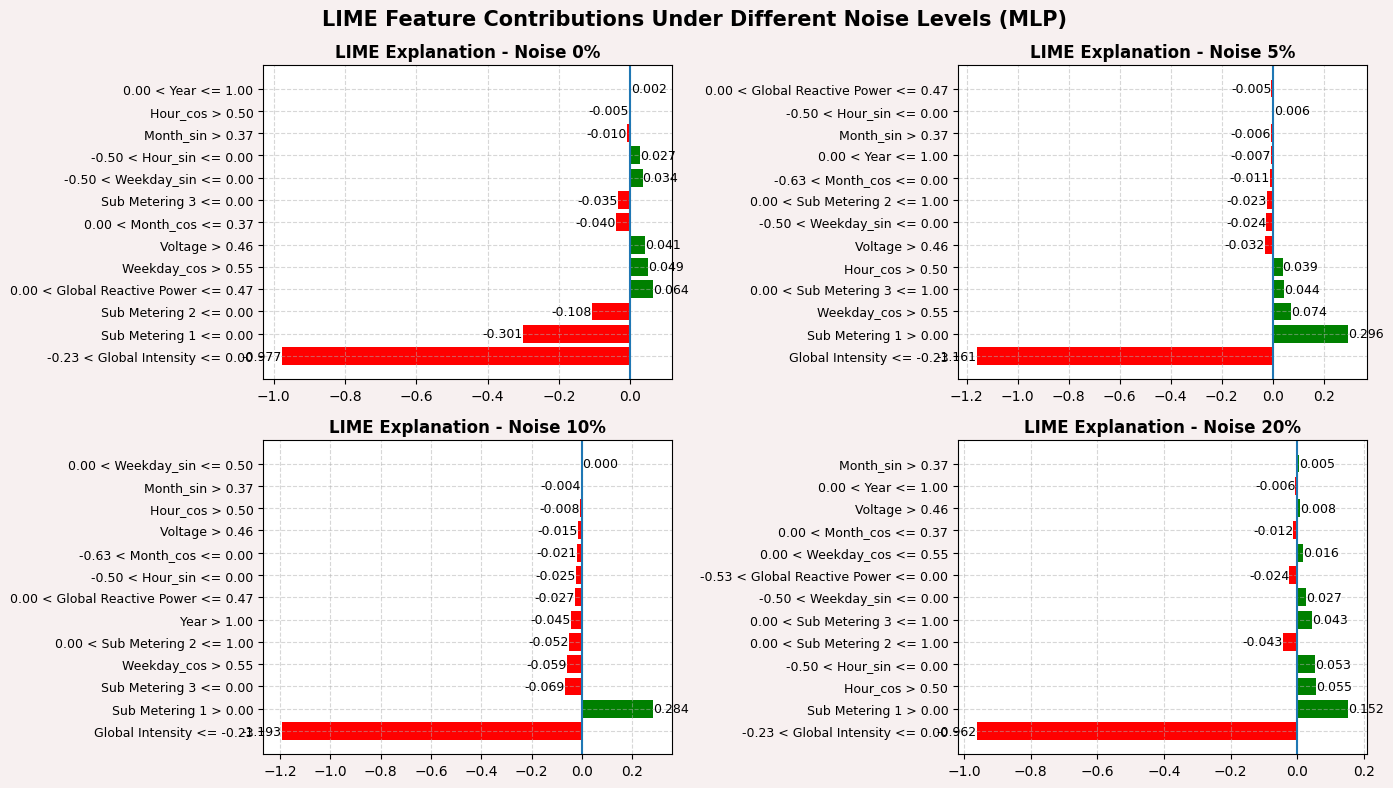

In [ ]:
# Plot LIME explanations

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor="#F7F0F0")
axes = axes.flatten()
for i, (noise, exp) in enumerate(explanations_mlp):

    # Extract feature contributions
    features = [f[0] for f in exp.as_list()]
    values = [f[1] for f in exp.as_list()]

    # LIME colors
    colors = ['green' if v > 0 else 'red' for v in values]

    # Horizontal bar plot
    bars = axes[i].barh(features, values, color=colors)

    # Add contribution values
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left' if width > 0 else 'right', fontsize=9)

    # Formatting
    axes[i].set_title(f"LIME Explanation - Noise {int(noise*100)}%", fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].axvline(0)

# Overall title
plt.suptitle("LIME Feature Contributions Under Different Noise Levels (MLP)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

LIME results for the MLP model show Global Intensity as the dominant feature, with strong negative contributions from about −0.98 to −1.19 across all noise levels. Sub Metering 1 remains influential, shifting from about −0.30 at zero noise to 0.28 at ten percent noise, suggesting sensitivity. Weekday_cos varies between 0.07 and −0.06, while Voltage fluctuates between 0.04 and −0.03, indicating instability. At 20% noise, Hour_cos near 0.06 and Hour_sin near 0.05 gain influence unexpectedly. Global Reactive Power and Sub Metering 2 show moderate variation. Hour-based and trigonometric calendar features appear potentially unreliable under noise due to inconsistent contributions and frequent sign changes.


In [ ]:
# Print contribution values for each noise level
print("\n" + "="*60)
print("LIME Feature Contributions at Different Noise Levels (MLP)")
print("="*60)
for noise, exp in explanations_mlp:
    print(f"\nNoise Level: {int(noise*100)}%")
    print("-"*45)

    # Print each feature contribution
    for feature, value in exp.as_list():
        print(f"{feature:30s}: {value:.4f}")


LIME Feature Contributions at Different Noise Levels (MLP)

Noise Level: 0%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -0.9768
Sub Metering 1 <= 0.00        : -0.3009
Sub Metering 2 <= 0.00        : -0.1082
0.00 < Global Reactive Power <= 0.47: 0.0643
Weekday_cos > 0.55            : 0.0495
Voltage > 0.46                : 0.0415
0.00 < Month_cos <= 0.37      : -0.0402
Sub Metering 3 <= 0.00        : -0.0353
-0.50 < Weekday_sin <= 0.00   : 0.0341
-0.50 < Hour_sin <= 0.00      : 0.0270
Month_sin > 0.37              : -0.0105
Hour_cos > 0.50               : -0.0050
0.00 < Year <= 1.00           : 0.0022

Noise Level: 5%
---------------------------------------------
Global Intensity <= -0.23     : -1.1610
Sub Metering 1 > 0.00         : 0.2960
Weekday_cos > 0.55            : 0.0739
0.00 < Sub Metering 3 <= 1.00 : 0.0441
Hour_cos > 0.50               : 0.0390
Voltage > 0.46                : -0.0316
-0.50 < Weekday_sin <= 0.00   : -0.0241
0.00 < Sub Meter

## **CNN**

In [ ]:
# Create LIME explainer
cnn_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression',
    verbose=False
)

# Custom prediction function
# LIME sends 2D input but CNN expects 3D input
def cnn_predict_fn(x):

    # Convert to df to preserve feature names
    x_df = pd.DataFrame(x, columns=X_train.columns)

    # Reshape for CNN
    x_cnn = x_df.values.reshape(x_df.shape[0], 1, x_df.shape[1])

    # Predict
    preds = cnn_model.predict(x_cnn, verbose=0)

    return preds.flatten()

In [ ]:
# Store explanations
explanations_cnn = []

# Generate LIME explanations
for noise in noise_levels:

    # Add Gaussian noise
    if noise == 0:
        X_temp = X_test.copy()
    else:
        X_temp = X_test + noise * np.random.normal(size=X_test.shape)

    # Select same sample
    sample_temp = X_temp.iloc[sample_idx].values

    # Generate explanation
    exp_temp = cnn_explainer.explain_instance(
        sample_temp,
        cnn_predict_fn,
        num_features=13
    )
    explanations_cnn.append((noise, exp_temp))

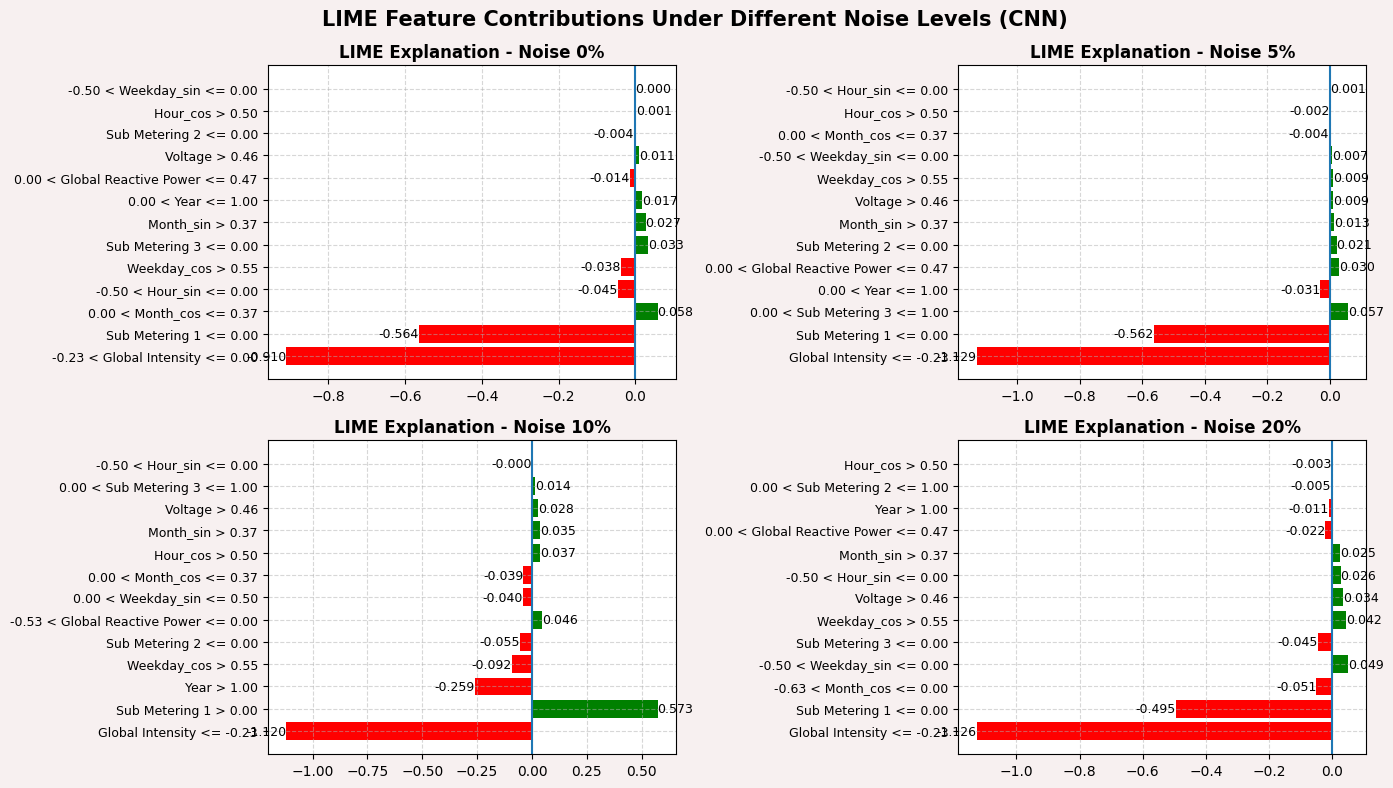

In [ ]:
# Plot explanations
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor="#F7F0F0")
axes = axes.flatten()

for i, (noise, exp) in enumerate(explanations_cnn):

    # Extract features and contributions
    features = [f[0] for f in exp.as_list()]
    values = [f[1] for f in exp.as_list()]

    # LIME colors
    colors = ['green' if v > 0 else 'red' for v in values]

    # Plot bars
    bars = axes[i].barh(features, values, color=colors)

    # Add annotations
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', ha='left' if width > 0 else 'right', fontsize=9)

    # Formatting
    axes[i].set_title(f"LIME Explanation - Noise {int(noise*100)}%", fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='y', labelsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].axvline(0)

# Overall title
plt.suptitle("LIME Feature Contributions Under Different Noise Levels (CNN)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

LIME analysis for the CNN model shows Global Intensity as the most stable feature, with strong negative contributions ranging from about −0.91 to −1.13 across all noise levels. Sub Metering 1 remains highly influential, shifting between about −0.56 and 0.57 at 10% noise, indicating sensitivity. Year becomes unstable at 10% noise with a contribution near −0.26. Weekday_cos fluctuates between about −0.09 and 0.04, while Month_cos and Month_sin vary around ±0.05. Voltage increases gradually to about 0.03 under higher noise. Calendar and temporal sine–cosine features, along with Year, appear potentially unreliable due to sign changes and inconsistent contributions under increasing noise levels.


In [ ]:
# Print contribution values for each noise level
print("\n" + "="*60)
print("LIME Feature Contributions at Different Noise Levels (CNN)")
print("="*60)
for noise, exp in explanations_cnn:
    print(f"\nNoise Level: {int(noise*100)}%")
    print("-"*45)

    # Print each feature contribution
    for feature, value in exp.as_list():
        print(f"{feature:30s}: {value:.4f}")


LIME Feature Contributions at Different Noise Levels (CNN)

Noise Level: 0%
---------------------------------------------
-0.23 < Global Intensity <= 0.00: -0.9099
Sub Metering 1 <= 0.00        : -0.5641
0.00 < Month_cos <= 0.37      : 0.0581
-0.50 < Hour_sin <= 0.00      : -0.0446
Weekday_cos > 0.55            : -0.0380
Sub Metering 3 <= 0.00        : 0.0334
Month_sin > 0.37              : 0.0268
0.00 < Year <= 1.00           : 0.0174
0.00 < Global Reactive Power <= 0.47: -0.0142
Voltage > 0.46                : 0.0107
Sub Metering 2 <= 0.00        : -0.0042
Hour_cos > 0.50               : 0.0011
-0.50 < Weekday_sin <= 0.00   : 0.0005

Noise Level: 5%
---------------------------------------------
Global Intensity <= -0.23     : -1.1290
Sub Metering 1 <= 0.00        : -0.5623
0.00 < Sub Metering 3 <= 1.00 : 0.0568
0.00 < Year <= 1.00           : -0.0314
0.00 < Global Reactive Power <= 0.47: 0.0300
Sub Metering 2 <= 0.00        : 0.0209
Month_sin > 0.37              : 0.0135
Voltage > 0

# **Conclusion**

---

Increasing input noise negatively impacts the predictive performance of all models trained on household power consumption data. As noise rises from zero to 20%, MAE and RMSE steadily increase, while R2 decreases. Linear Regression and CNN show higher sensitivity to noise, whereas Random Forest and MLP are more robust, maintaining lower errors and higher R2 values. Model accuracy deteriorates with noise, highlighting the importance of clean, stable input features for reliable predictions.

---

Explainability methods like LIME effectively reveal robustness weaknesses in safety-critical machine learning systems. They show that dominant features, such as Global Intensity, remain stable under low noise, while temporal and metering features fluctuate or reverse contributions as noise increases.

---

Local explanations highlight which features become unreliable under sensor noise, enabling identification of sensitive inputs, instability and potential failure points, thus guiding model improvement and ensuring safer, more trustworthy predictions in noisy real-world environments.

---
**Challenge :**
Random search was initially considered for hyperparameter tuning of the models. However due to the large size of the dataset the method proved to be computationally expensive and time consuming. As a result it was skipped.



